[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jinming99/learn-ml-by-building/blob/main/Lecture%206%20Evaluation%20Pitfalls%20and%20Data%20Visualization/06-ModelEval.ipynb)

# Data Understanding & Model Evaluation
## What Did That Number Leave Out?

A neat summary or a high score can leave out the part we care about most. We'll start with the data, follow one fraud detector from accuracy to financial consequences, and finish by asking whether a model could have made its predictions at the right moment.

### Data and setup

Local files are used when available; otherwise the notebook downloads the public data automatically. [Datasaurus](https://www.openintro.org/data/index.php?data=datasaurus) comes from OpenIntro, [credit-card fraud](https://www.openml.org/d/42175) from OpenML, and the **33-column Telco workbook, including `Churn Reason`,** comes directly from [IBM](https://public.dhe.ibm.com/software/data/sw-library/cognos/mobile/C11/data/). Tips and penguins are small copies in this course repository. Berkeley's canonical count table is included below with its source. Downloads are cached beside the notebook so subsequent runs can work offline.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'grid.alpha': 0.20, 'figure.dpi': 110})
COLORS = {'blue': '#3A86FF', 'teal': '#2A9D8F', 'coral': '#E76F51',
          'purple': '#8338EC', 'ink': '#263238', 'muted': '#8D99AE'}


def data_path(filename):
    """Prefer local files; cache public downloads for future offline runs."""
    from urllib.request import Request, urlopen
    from urllib.parse import quote
    folders = [Path.cwd(), Path.cwd() / 'Lecture 6 Evaluation Pitfalls and Data Visualization']
    for folder in folders:
        if (folder / filename).exists():
            return folder / filename
    target = Path.cwd() / filename
    if filename == 'creditcard.csv':
        from sklearn.datasets import fetch_openml
        frame = fetch_openml(data_id=42175, as_frame=True).frame
        frame['Class'] = pd.to_numeric(frame['Class'].astype(str), errors='raise').astype(int)
        assert frame.shape == (284807, 31) and frame['Class'].sum() == 492
        frame.to_csv(target, index=False)
    else:
        urls = {
            'datasaurus.csv': 'https://www.openintro.org/data/csv/datasaurus.csv',
            'Telco_customer_churn.xlsx': 'https://public.dhe.ibm.com/software/data/sw-library/cognos/mobile/C11/data/Telco_customer_churn.xlsx',
        }
        repo = 'https://raw.githubusercontent.com/jinming99/learn-ml-by-building/main/'
        url = urls.get(filename, repo + quote('Lecture 6 Evaluation Pitfalls and Data Visualization/' + filename))
        request = Request(url, headers={'User-Agent': 'curl/8.7.1'})
        with urlopen(request, timeout=120) as response:
            content = response.read()
        target.write_bytes(content)
    return target


def style_axes(ax, title='', xlabel='', ylabel='', percent_x=False):
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.spines[['top', 'right']].set_visible(False)
    if percent_x:
        ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))


def compact_table(frame, formats=None):
    display(frame.style.hide(axis='index').format(formats or {}))

## Part 1: What Do These Summaries Tell Us?

Here are 13 datasets. Before looking at any plots, compare their means, standard deviations, and correlations. How much do these numbers let us conclude about their shapes?

In [2]:
datasaurus = pd.read_csv(data_path('datasaurus.csv'))
summary_rows = []
for number, (name, group) in enumerate(datasaurus.groupby('dataset'), start=1):
    summary_rows.append({'Dataset': number, 'Mean x': group.x.mean(), 'Mean y': group.y.mean(),
                         'SD x': group.x.std(), 'SD y': group.y.std(),
                         'Correlation': group.x.corr(group.y)})
compact_table(pd.DataFrame(summary_rows), {key: '{:.2f}' for key in summary_rows[0] if key != 'Dataset'})

Dataset,Mean x,Mean y,SD x,SD y,Correlation
1,54.27,47.83,16.77,26.94,-0.06
2,54.27,47.83,16.77,26.94,-0.07
3,54.27,47.84,16.76,26.93,-0.07
4,54.26,47.83,16.77,26.94,-0.06
5,54.26,47.84,16.77,26.93,-0.06
6,54.26,47.83,16.77,26.94,-0.06
7,54.27,47.84,16.77,26.94,-0.07
8,54.27,47.84,16.77,26.94,-0.07
9,54.27,47.83,16.77,26.94,-0.07
10,54.27,47.84,16.77,26.93,-0.06


### Now look at the points

What could we see here that the table couldn't tell us?

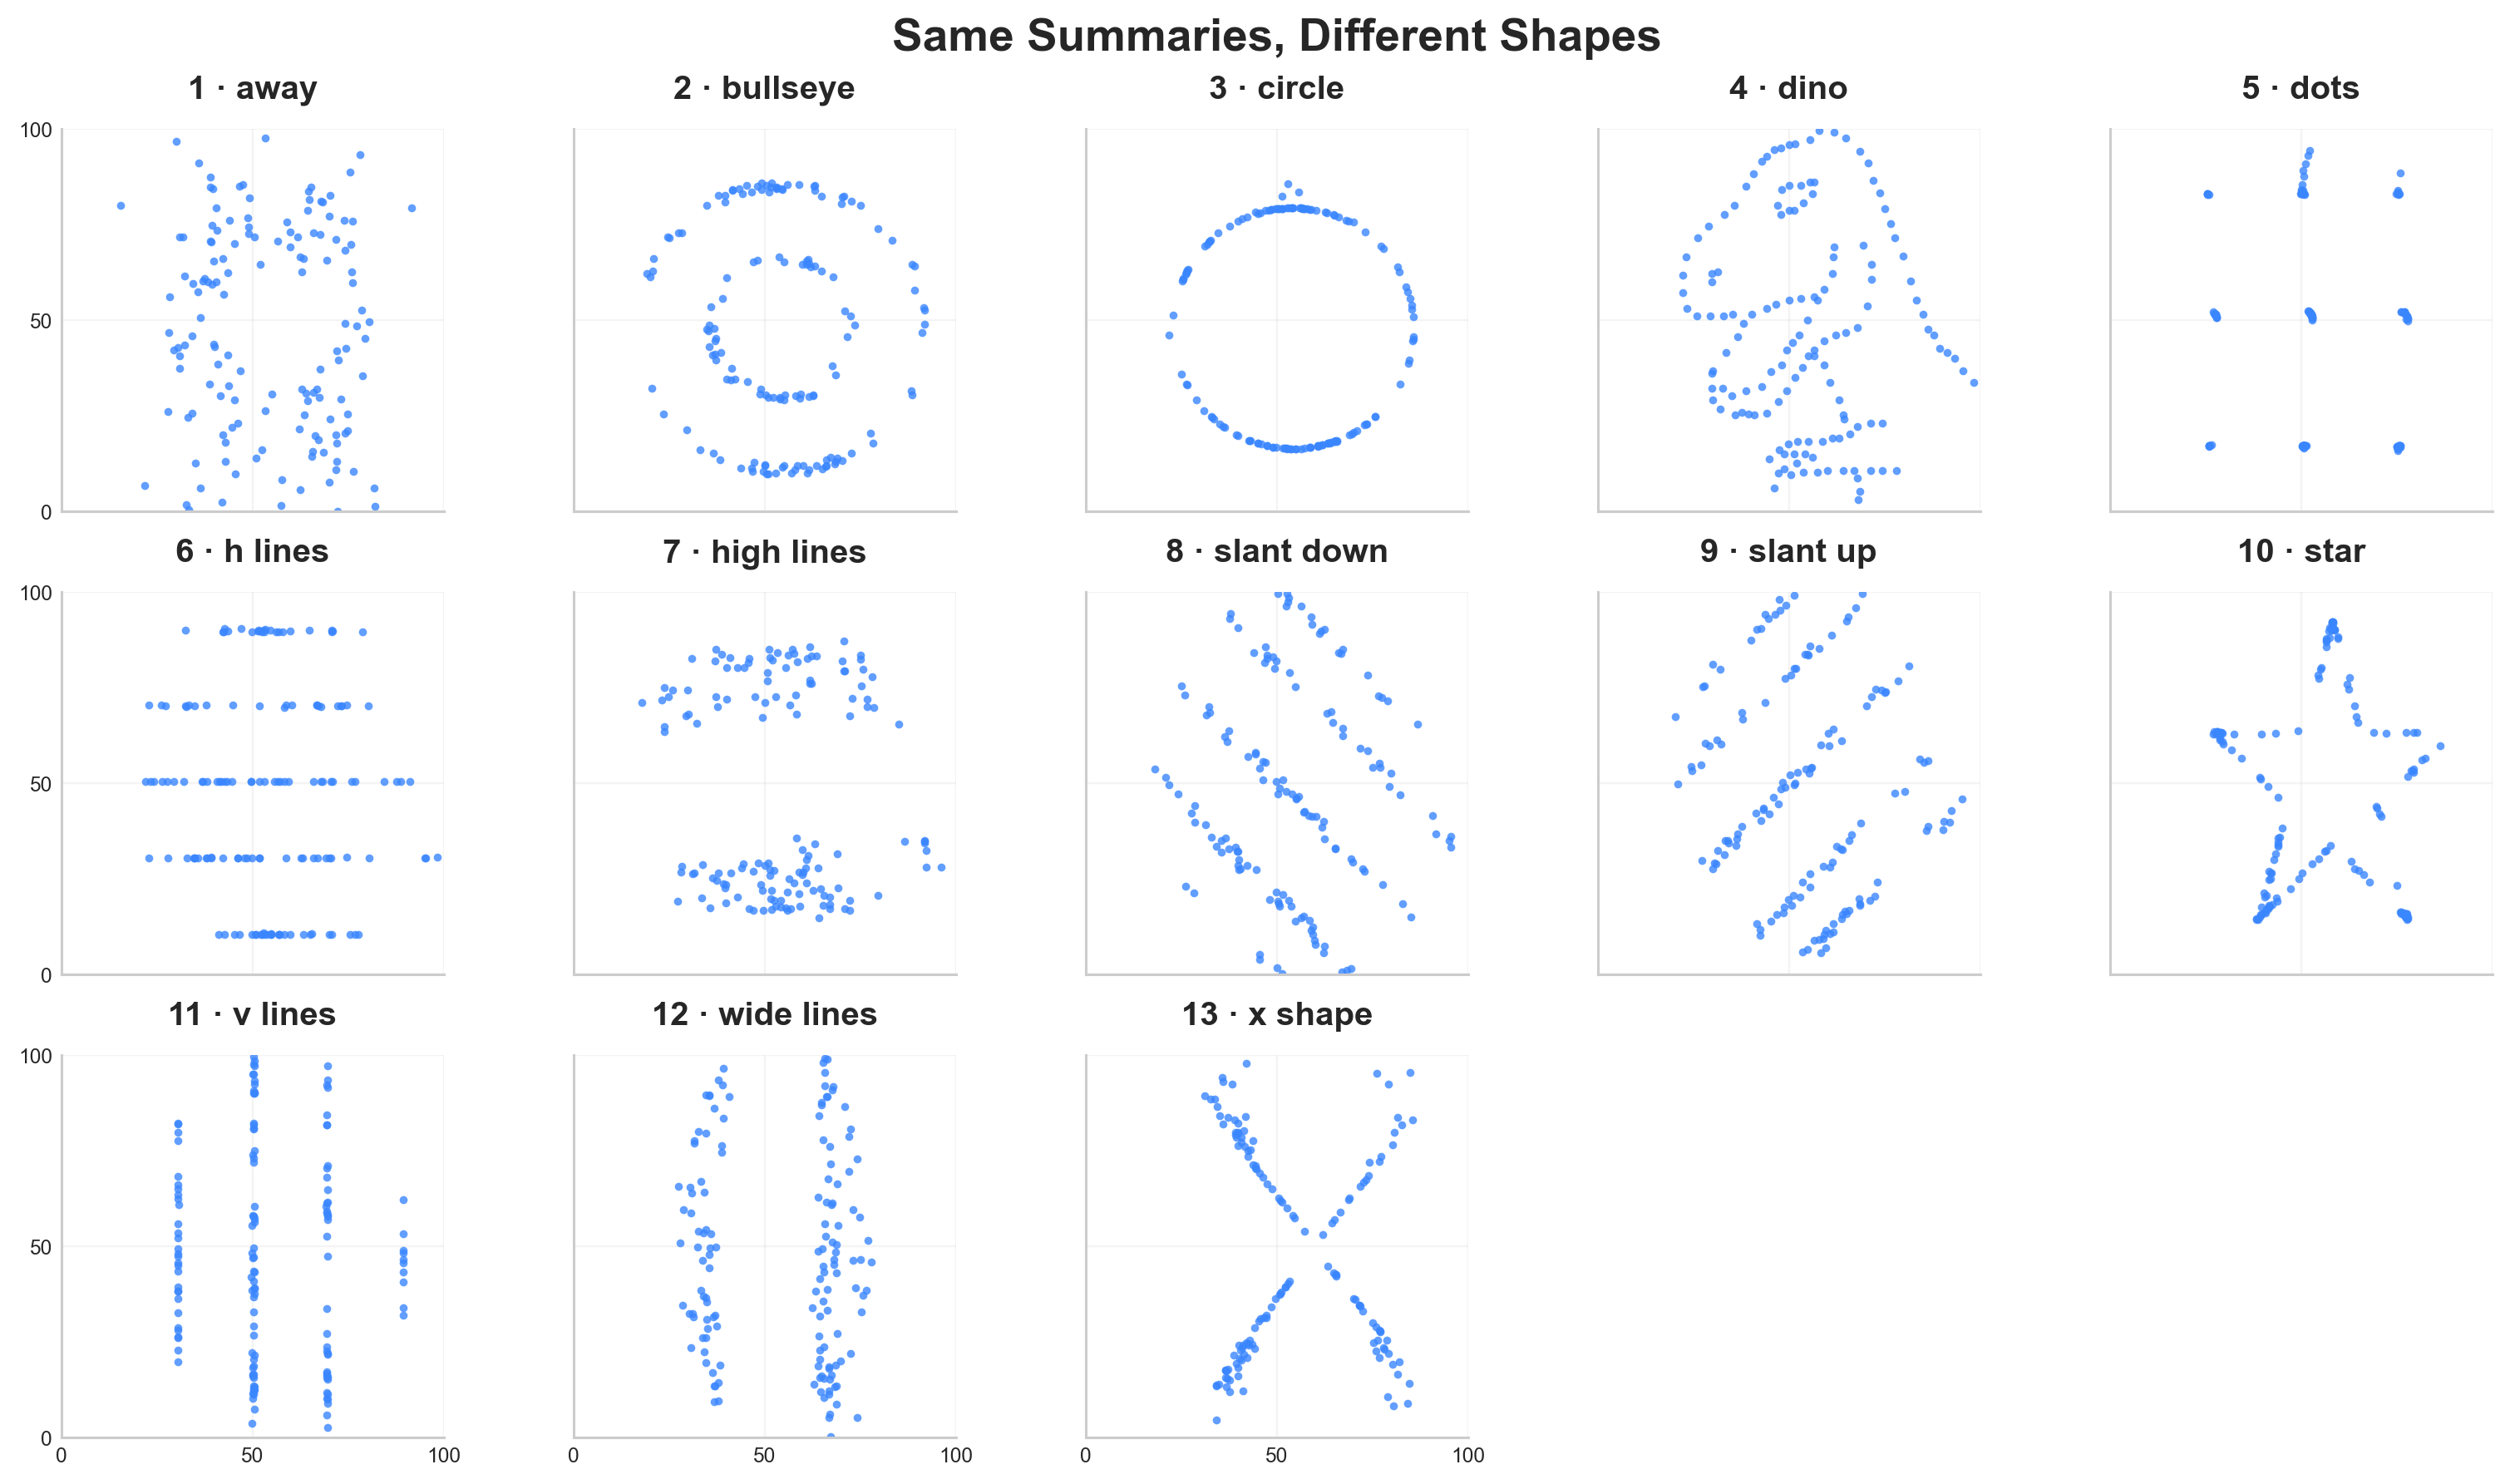

In [3]:
fig, axes = plt.subplots(3, 5, figsize=(14, 8), sharex=True, sharey=True, layout='constrained')
for number, (ax, (name, group)) in enumerate(zip(axes.flat, datasaurus.groupby('dataset')), start=1):
    ax.scatter(group.x, group.y, s=10, color=COLORS['blue'], alpha=0.8, linewidths=0)
    ax.set(title=f'{number} · {name.replace("_", " ")}', xlim=(0, 100), ylim=(0, 100))
    ax.set_aspect('equal')
    ax.set_xticks([0, 50, 100])
    ax.set_yticks([0, 50, 100])
    ax.tick_params(labelsize=8)
for ax in axes.flat[len(summary_rows):]:
    ax.remove()
fig.suptitle('Same Summaries, Different Shapes', fontsize=18, fontweight='bold')
plt.show()

Those statistics weren't wrong. They just left out the structure. All 13 datasets have nearly the same means, standard deviations, and correlation, yet they tell very different visual stories. A small correlation does not mean there is no pattern.

## Part 2: What Did the Overall Average Hide?

These are the six largest departments in Berkeley's 1973 graduate admissions data. Start with the overall admission rates. What would you want to know before explaining the gap?

**Source:** the canonical [`UCBAdmissions` counts](https://github.com/wch/r-source/blob/trunk/src/library/datasets/data/UCBAdmissions.R), covering 4,526 applications. These are the six-department totals, not the university-wide totals. We use this table because the previously used local CSV disagrees with these published counts.

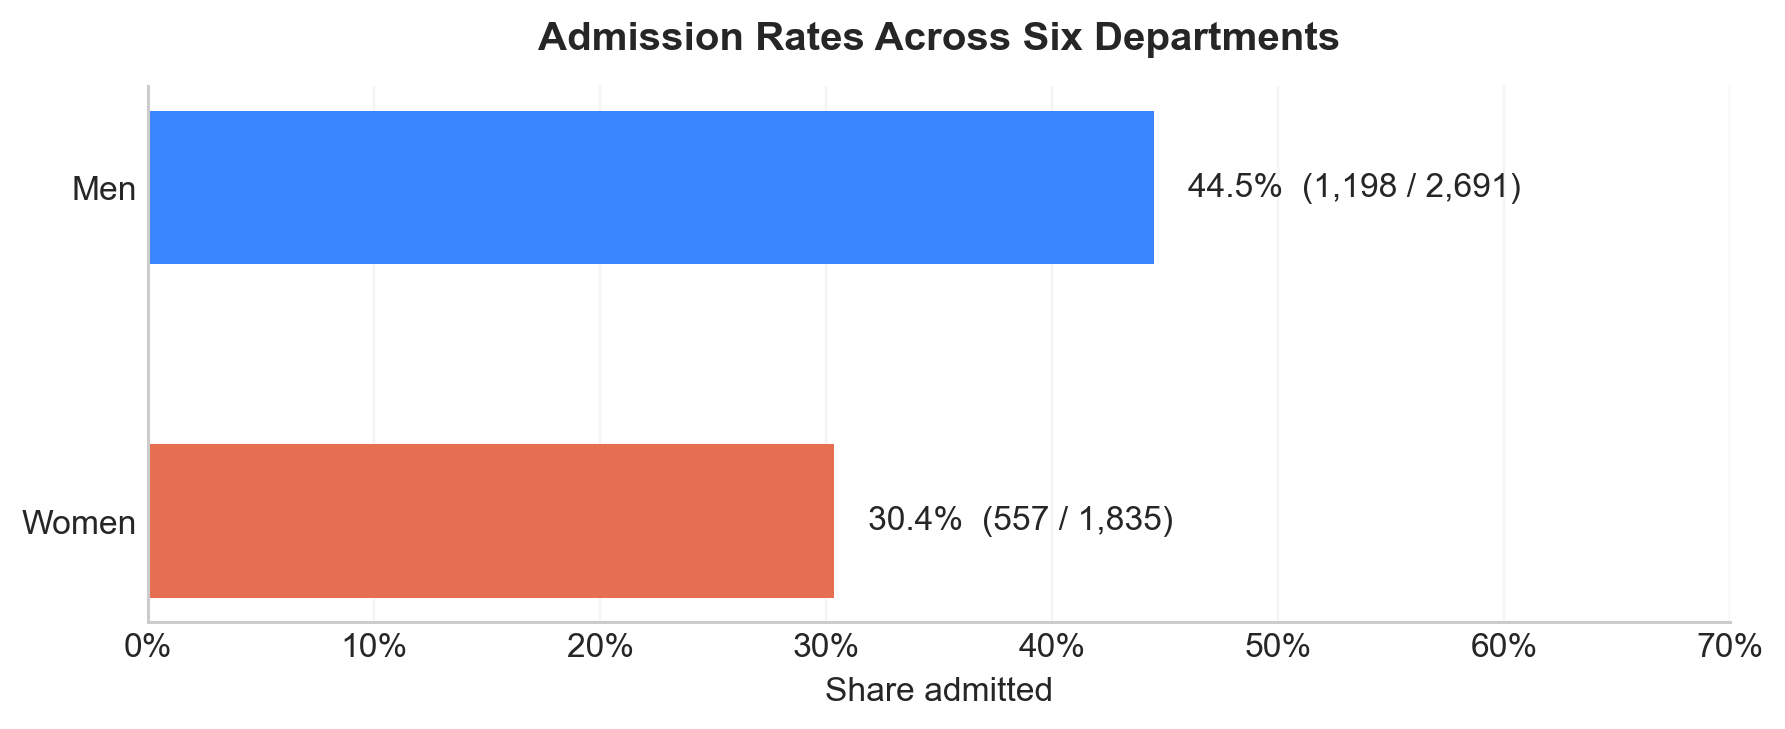

In [4]:
# Each pair is [admitted, rejected], transcribed from R's UCBAdmissions dataset.
counts = {'A': [[512, 313], [89, 19]], 'B': [[353, 207], [17, 8]],
          'C': [[120, 205], [202, 391]], 'D': [[138, 279], [131, 244]],
          'E': [[53, 138], [94, 299]], 'F': [[22, 351], [24, 317]]}
admissions = pd.DataFrame([
    {'Department': dept, 'Gender': gender, 'Admitted': pair[0], 'Applicants': sum(pair)}
    for dept, pairs in counts.items()
    for gender, pair in zip(['Men', 'Women'], pairs)
])
admissions['Rate'] = admissions.Admitted / admissions.Applicants
admissions['Application share'] = admissions.Applicants / admissions.groupby('Gender').Applicants.transform('sum')
overall = admissions.groupby('Gender')[['Admitted', 'Applicants']].sum()
overall['Rate'] = overall.Admitted / overall.Applicants
gender_colors = {'Men': COLORS['blue'], 'Women': COLORS['coral']}

fig, ax = plt.subplots(figsize=(8, 3.2), layout='constrained')
for i, (gender, row) in enumerate(overall.iterrows()):
    ax.barh(i, row.Rate, height=0.46, color=gender_colors[gender])
    ax.text(row.Rate + 0.015, i, f'{row.Rate:.1%}  ({int(row.Admitted):,} / {int(row.Applicants):,})', va='center')
ax.set_yticks([0, 1], overall.index)
ax.invert_yaxis()
ax.set_xlim(0, 0.70)
ax.grid(axis='y', visible=False)
style_axes(ax, 'Admission Rates Across Six Departments', 'Share admitted', percent_x=True)
plt.show()

### Keep the departments visible

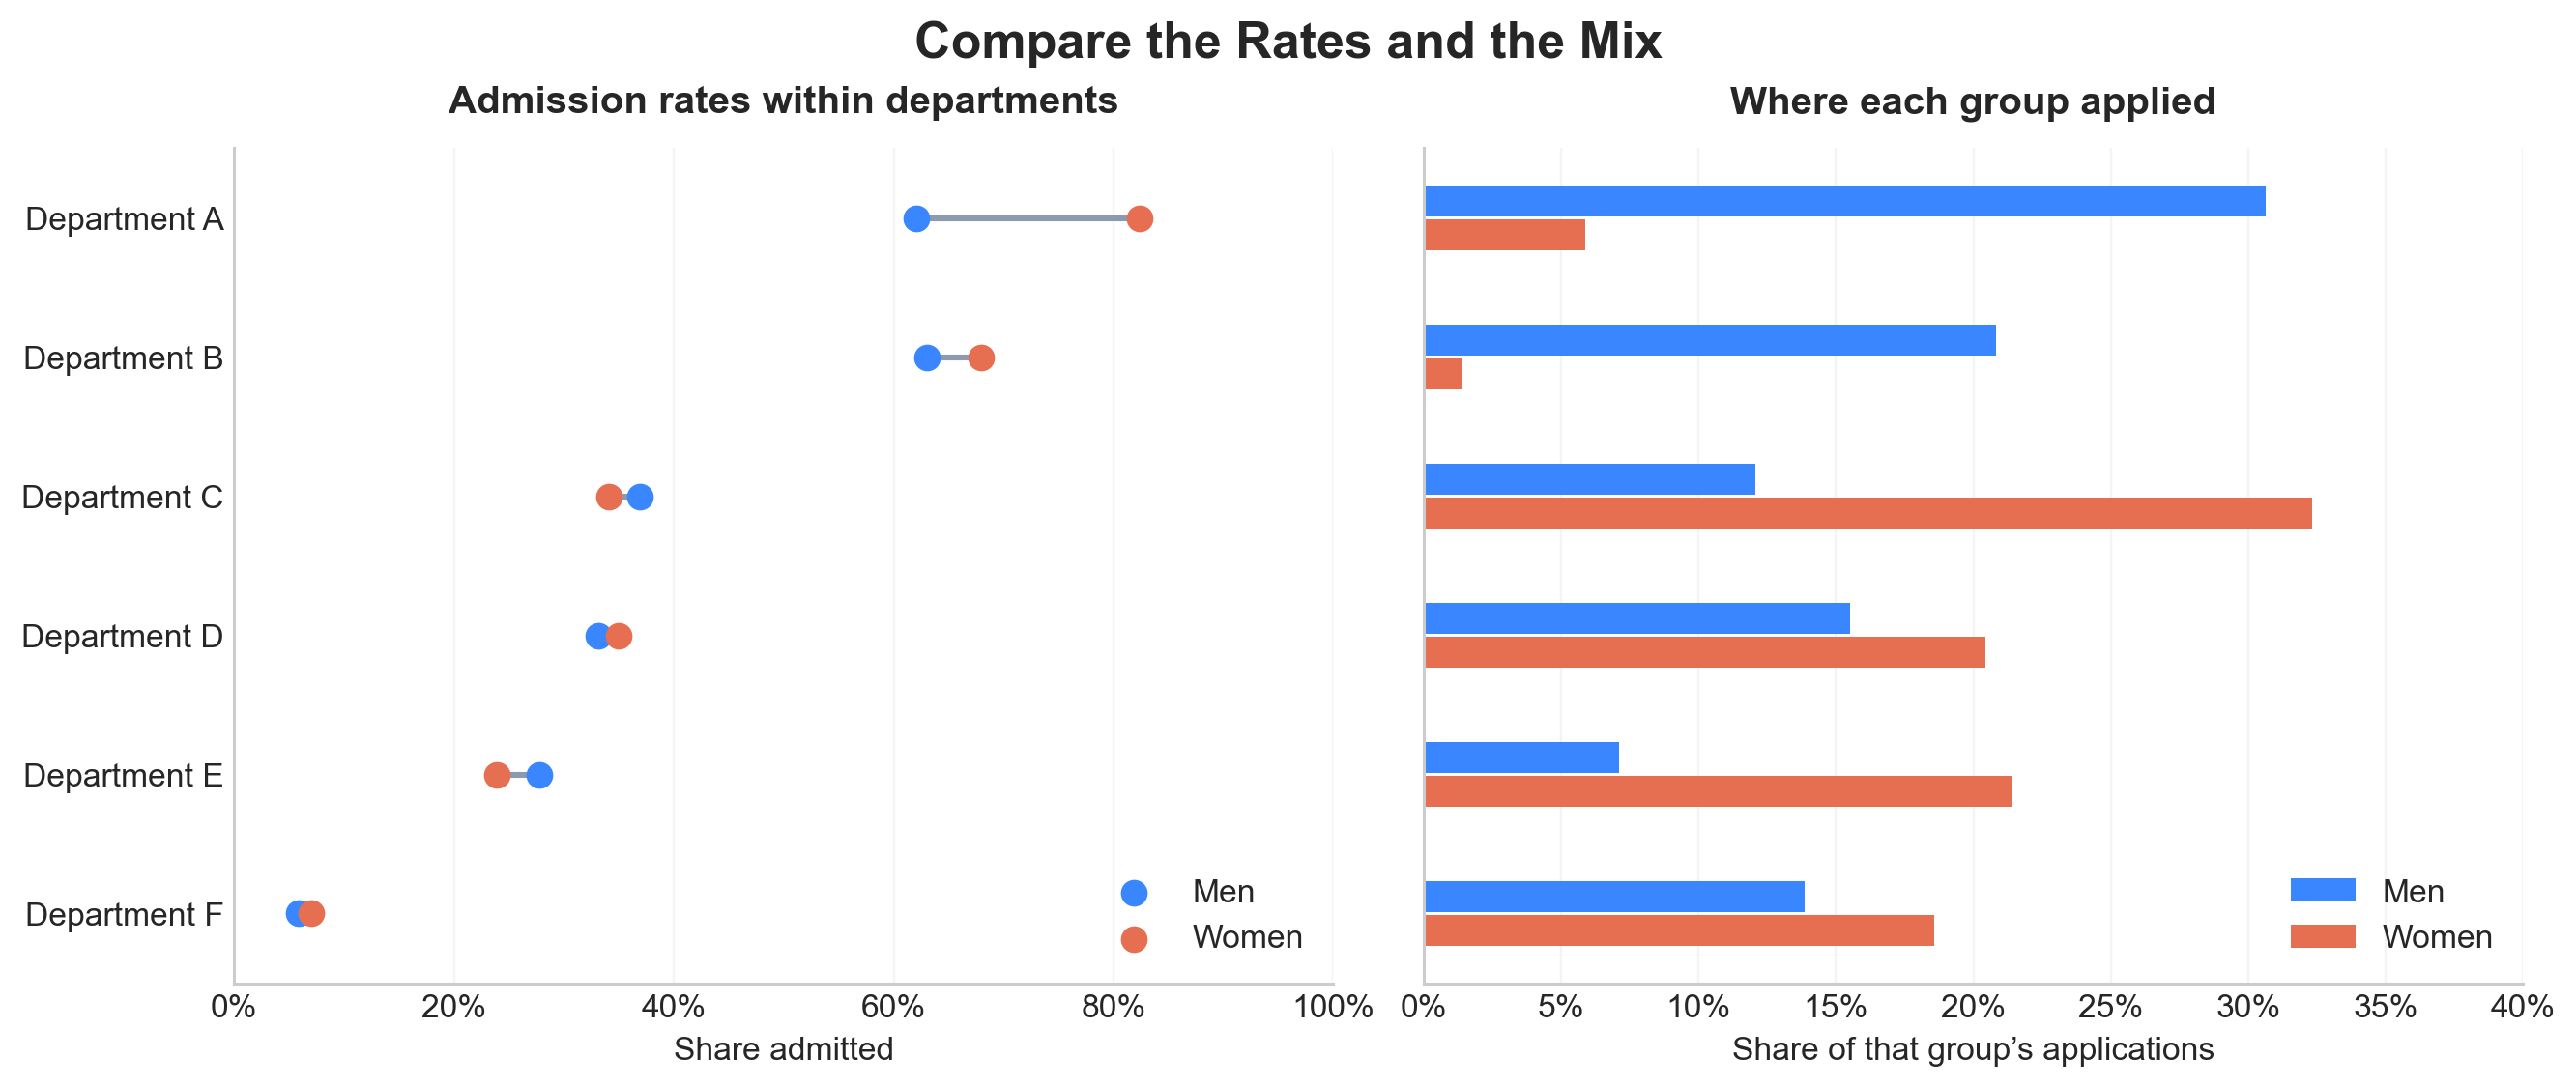

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, layout='constrained')
positions = np.arange(6)
rates = admissions.pivot(index='Department', columns='Gender', values='Rate')
axes[0].hlines(positions, rates.Men, rates.Women, color=COLORS['muted'], linewidth=2)
for gender, offset in [('Men', -0.12), ('Women', 0.12)]:
    rows = admissions[admissions.Gender.eq(gender)].set_index('Department').loc[list(counts)]
    axes[0].scatter(rows.Rate, positions, color=gender_colors[gender], s=65, label=gender, zorder=3)
    axes[1].barh(positions + offset, rows['Application share'], height=0.22,
                 color=gender_colors[gender], label=gender)
axes[0].set_yticks(positions, [f'Department {d}' for d in counts])
axes[0].invert_yaxis()
for ax, title, label, limit in zip(axes, ['Admission rates within departments', 'Where each group applied'],
                                  ['Share admitted', 'Share of that group’s applications'], [1, 0.4]):
    style_axes(ax, title, label, percent_x=True)
    ax.set_xlim(0, limit)
    ax.grid(axis='y', visible=False)
    ax.legend(frameon=False, loc='lower right')
fig.suptitle('Compare the Rates and the Mix', fontsize=17, fontweight='bold')
plt.show()

The overall admission rate is a weighted average. Women applied more often to departments with lower admission rates, so the two overall percentages combine different mixes of applications. The breakdown changes our interpretation, but these counts alone cannot establish why people applied where they did or settle the broader question of discrimination.

## Visual Vocabulary: Start with the Question

We've seen why we need to look at the data. Now let's ask how to look. We'll use restaurant bills, penguin measurements, and a small model-training experiment. In each case, the chart should make one particular question easier to answer.

### 1 · Relationships: what does one dot stand for?

Each dot is one restaurant bill. Do larger bills tend to come with larger tips? Does separating the recorded smoking groups help us see anything else? Both panels show exactly the same observations.

The small `tips.csv` and `penguins.csv` files beside this notebook are local copies of [Seaborn's example data](https://github.com/mwaskom/seaborn-data). The [Palmer Penguins project](https://allisonhorst.github.io/palmerpenguins/) documents the penguin measurements. This section also uses seaborn (0.12+); no live download is needed.

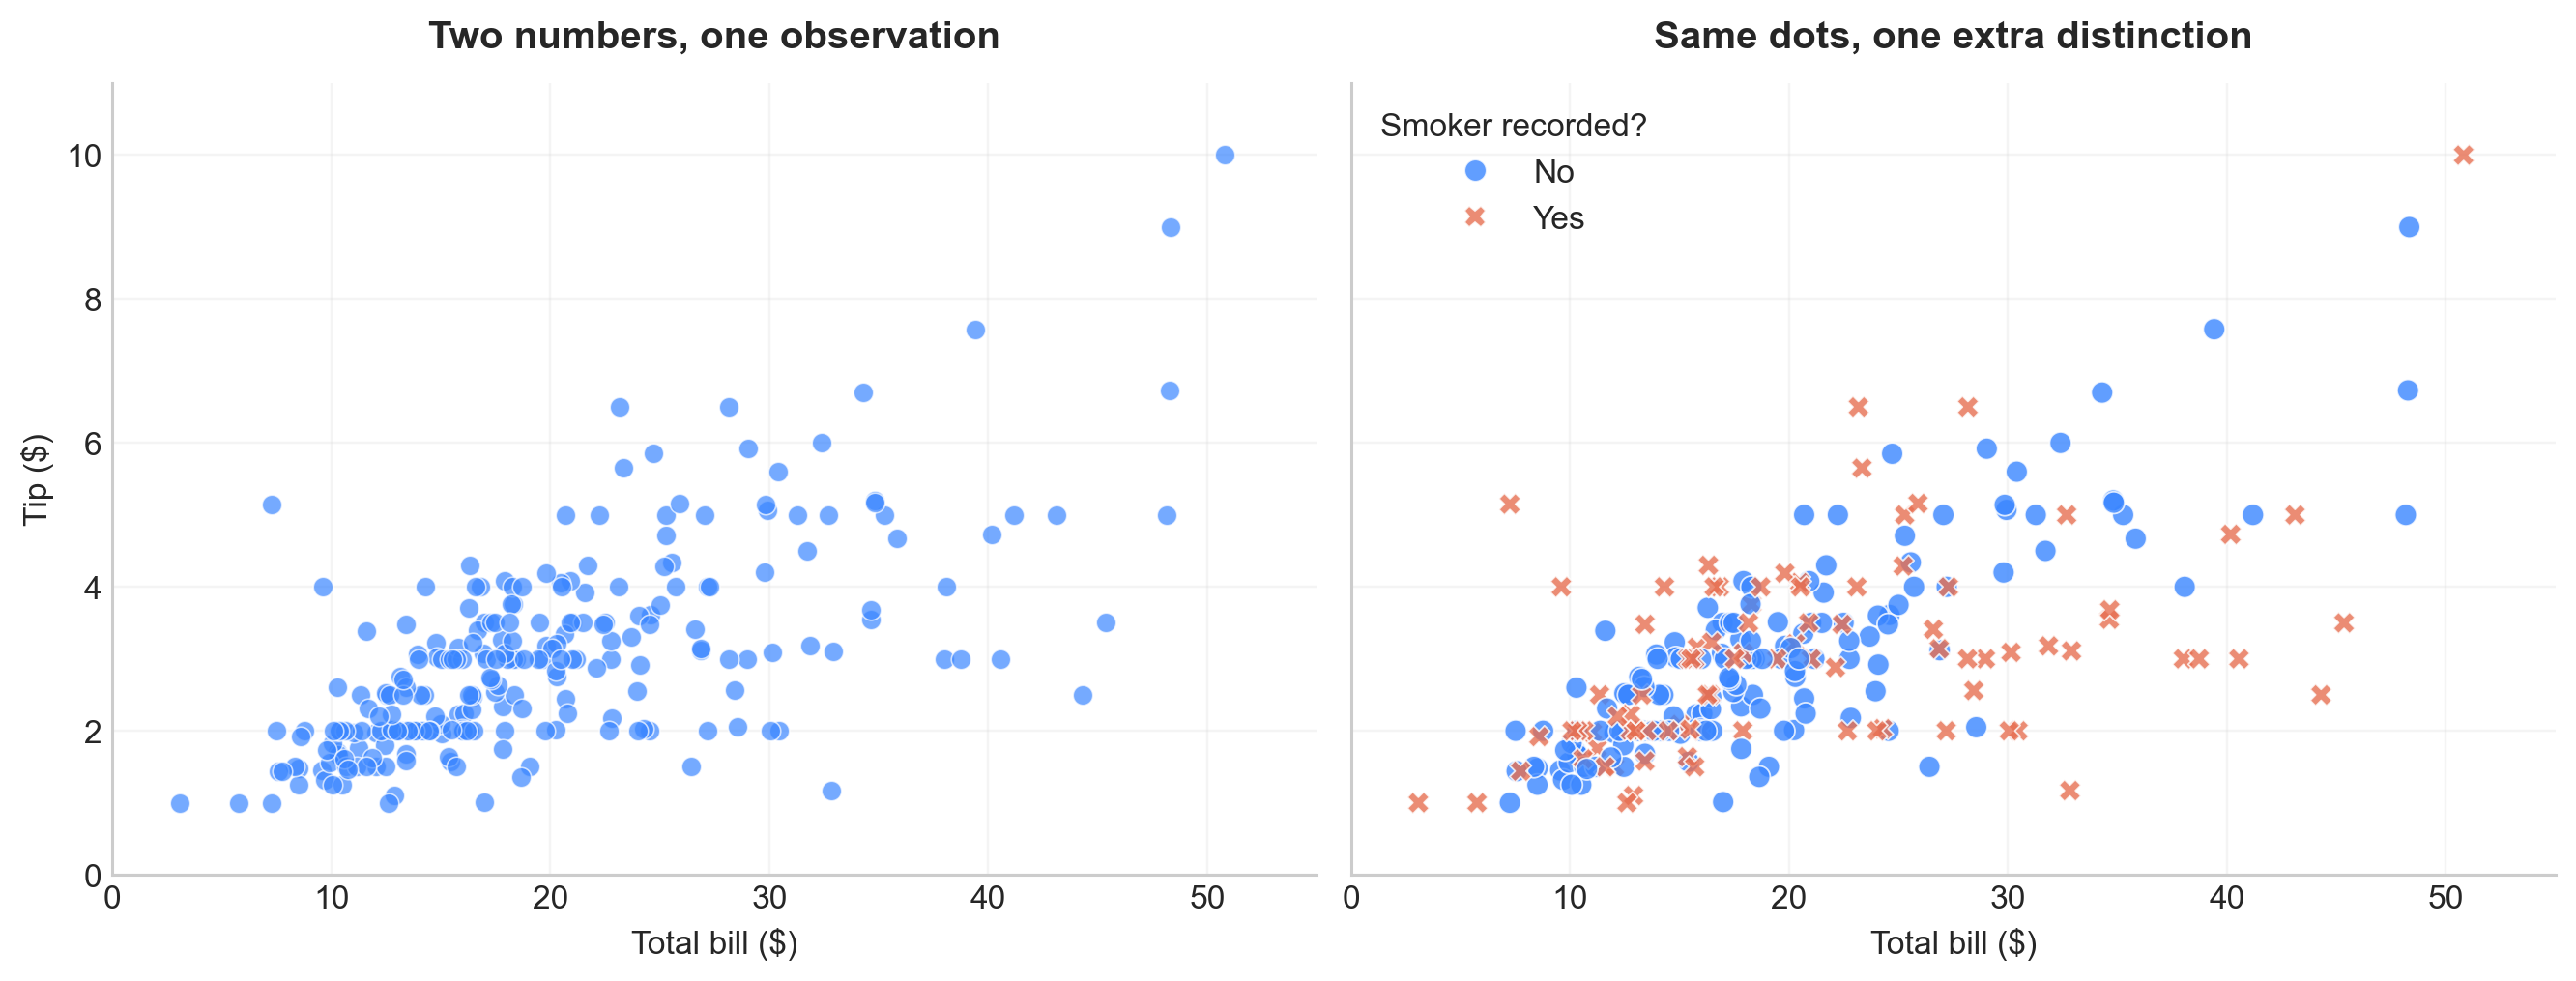

In [6]:
import seaborn as sns

tips = pd.read_csv(data_path('tips.csv'))
penguins = pd.read_csv(data_path('penguins.csv')).dropna(subset=['flipper_length_mm', 'bill_length_mm'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True, layout='constrained')
sns.scatterplot(data=tips, x='total_bill', y='tip', color=COLORS['blue'],
                s=45, alpha=0.7, ax=axes[0])
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', style='smoker',
                hue_order=['No', 'Yes'], style_order=['No', 'Yes'],
                palette=[COLORS['blue'], COLORS['coral']], markers=['o', 'X'],
                s=55, alpha=0.8, ax=axes[1])
for ax, title in zip(axes, ['Two numbers, one observation', 'Same dots, one extra distinction']):
    style_axes(ax, title, 'Total bill ($)', 'Tip ($)')
    ax.set(xlim=(0, 55), ylim=(0, 11))
axes[1].legend(title='Smoker recorded?', frameon=False)
plt.show()

A scatter plot keeps the individual cases visible, including the unusually large bill with a small tip. Color adds a grouping; shape repeats that grouping so color isn't the only cue. The groups overlap a lot, and this isn't evidence that smoking causes a change in tipping. We could map party size to marker size, but we'd only add that extra encoding if party size were our question. Connecting these unordered bills with a line would imply a sequence that isn't there.

### 2 · Categories: the average bill, or the range of bills?

Imagine you're planning restaurant staffing. Do you want the average bill on each day, or a sense of how much individual bills vary? Compare the same four days on the same dollar scale.

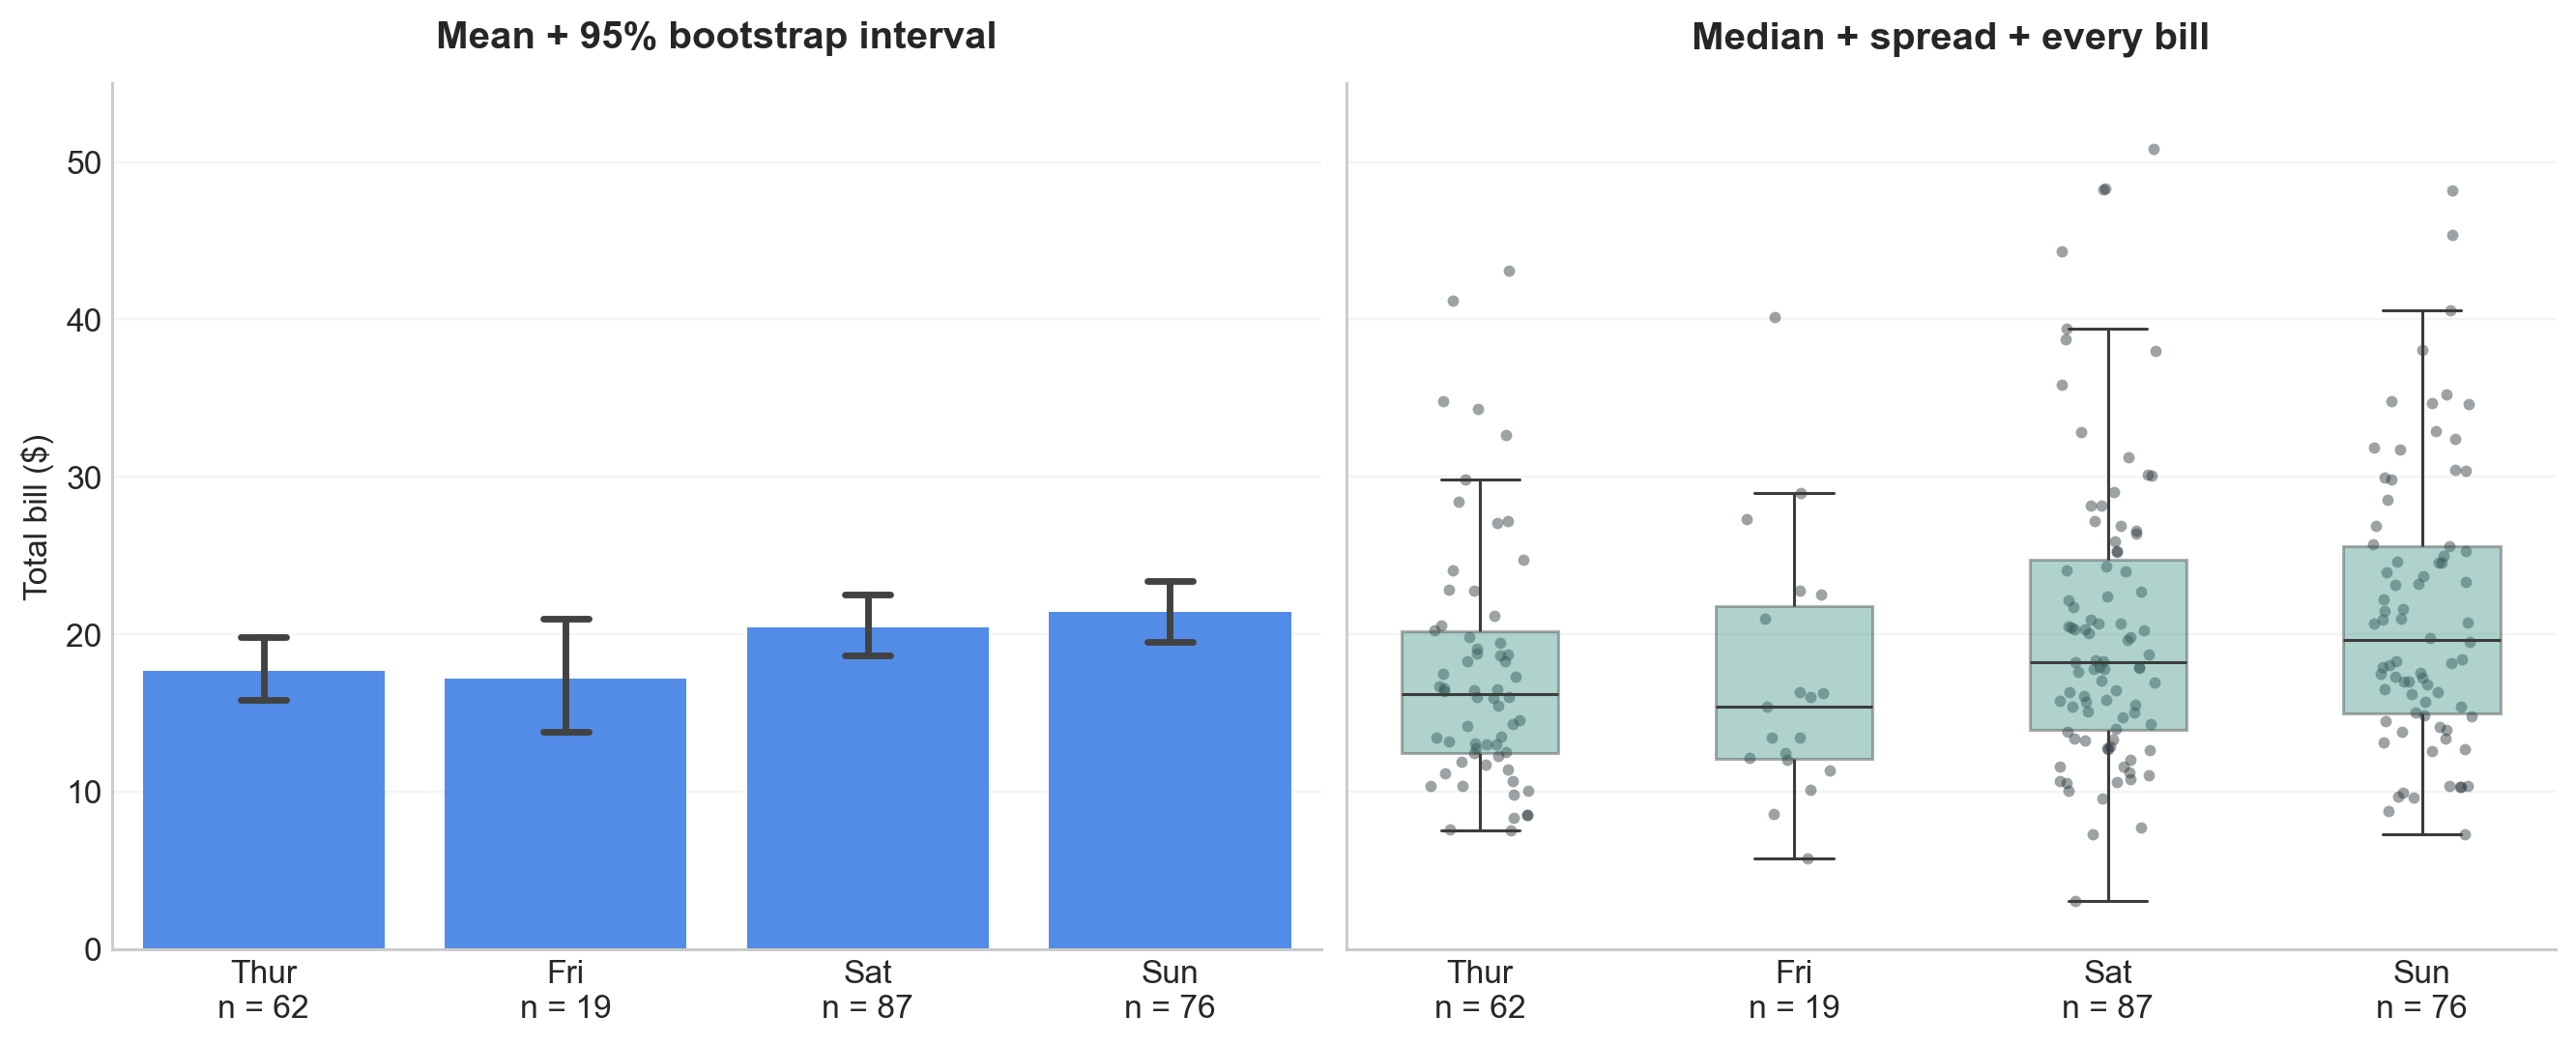

In [7]:
days = ['Thur', 'Fri', 'Sat', 'Sun']
day_labels = [f'{day}\nn = {tips.day.eq(day).sum()}' for day in days]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True, layout='constrained')
sns.barplot(data=tips, x='day', y='total_bill', order=days, color=COLORS['blue'],
            errorbar=('ci', 95), n_boot=2000, seed=42, capsize=0.15, ax=axes[0])
sns.boxplot(data=tips, x='day', y='total_bill', order=days, color=COLORS['teal'],
            width=0.5, showfliers=False, boxprops={'alpha': 0.4}, ax=axes[1])
# Fixed offsets keep individual observations visible and reproducible.
jitter = np.random.default_rng(42)
for i, day in enumerate(days):
    bills = tips.loc[tips.day.eq(day), 'total_bill']
    axes[1].scatter(i + jitter.uniform(-0.16, 0.16, len(bills)), bills,
                    s=15, alpha=0.45, color=COLORS['ink'], linewidths=0)
for ax, title in zip(axes, ['Mean + 95% bootstrap interval', 'Median + spread + every bill']):
    style_axes(ax, title, '', 'Total bill ($)')
    ax.set_xticks(range(4), day_labels)
    ax.set_ylim(0, 55)
    ax.grid(axis='x', visible=False)
plt.show()

The black intervals on the left describe uncertainty in the estimated **mean**, not the range of bills. On the right, the box contains the middle 50%, the line marks the median, and whiskers extend to the most extreme observations within 1.5 interquartile ranges of the box. The dots show every bill, including those beyond the whiskers. Friday has far fewer observations: neither plot turns this small observational sample into a reliable forecast. If we wanted a within-day group comparison, we could split the boxes by a second category; we don't need that extra layer for today's question.

### 3 · Distributions: one population, or a mixture?

These are measured penguins, not generated points. First look at flipper length alone. Then use the joint plot to connect flipper length, bill length, and species. Which view makes the groups easier to see?

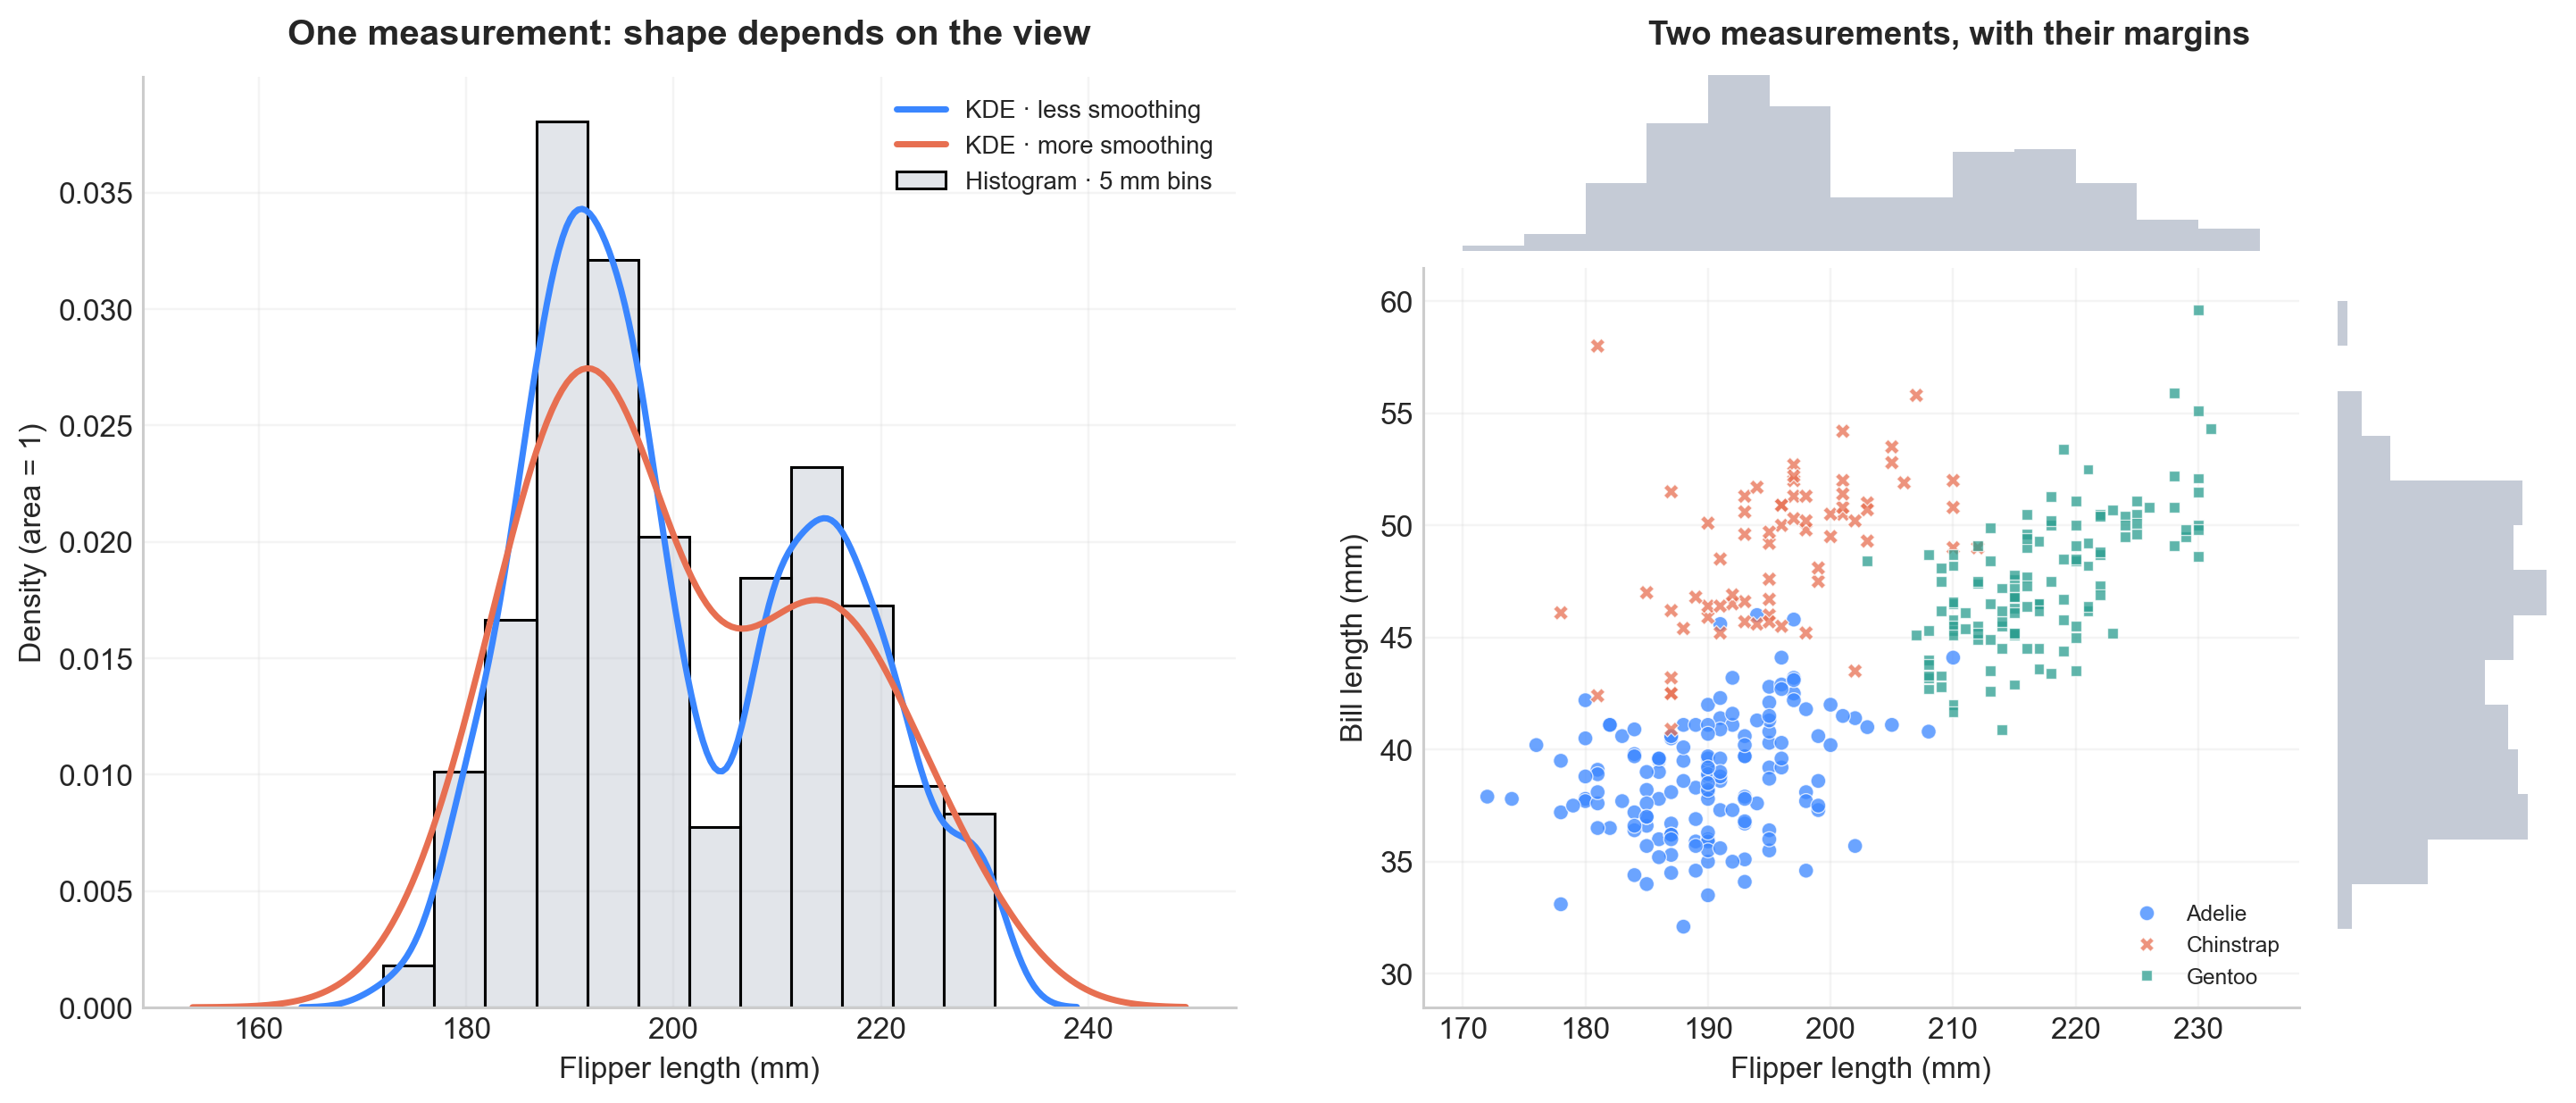

In [8]:
species_colors = dict(zip(['Adelie', 'Chinstrap', 'Gentoo'],
                          [COLORS['blue'], COLORS['coral'], COLORS['teal']]))
fig = plt.figure(figsize=(13, 5.5), layout='constrained')
left, right = fig.subfigures(1, 2, wspace=0.07)
dist_ax = left.subplots()
sns.histplot(data=penguins, x='flipper_length_mm', binwidth=5, stat='density',
             color=COLORS['muted'], alpha=0.25, ax=dist_ax, label='Histogram · 5 mm bins')
for smooth, color, label in [(0.6, COLORS['blue'], 'KDE · less smoothing'),
                              (1.4, COLORS['coral'], 'KDE · more smoothing')]:
    sns.kdeplot(data=penguins, x='flipper_length_mm', bw_adjust=smooth,
                color=color, linewidth=2.3, ax=dist_ax, label=label)
style_axes(dist_ax, 'One measurement: shape depends on the view', 'Flipper length (mm)', 'Density (area = 1)')
dist_ax.legend(frameon=False, fontsize=9)

grid = right.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.03, wspace=0.03)
joint_ax = right.add_subplot(grid[1, 0])
top_ax = right.add_subplot(grid[0, 0], sharex=joint_ax)
side_ax = right.add_subplot(grid[1, 1], sharey=joint_ax)
sns.scatterplot(data=penguins, x='flipper_length_mm', y='bill_length_mm', hue='species',
                style='species', palette=species_colors, s=30, alpha=0.75, ax=joint_ax)
top_ax.hist(penguins.flipper_length_mm, bins=np.arange(170, 236, 5), color=COLORS['muted'], alpha=0.5)
side_ax.hist(penguins.bill_length_mm, bins=np.arange(30, 62, 2), orientation='horizontal',
             color=COLORS['muted'], alpha=0.5)
style_axes(joint_ax, '', 'Flipper length (mm)', 'Bill length (mm)')
joint_ax.legend(title=None, frameon=False, fontsize=8, loc='lower right')
for ax in [top_ax, side_ax]:
    ax.grid(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
right.suptitle('Two measurements, with their margins', fontsize=12, fontweight='bold')
plt.show()

The histogram counts observations in bins; here its vertical scale is density so we can overlay the KDEs. Changing bin width or KDE bandwidth changes the picture. A smoother curve isn't automatically a truer one. The joint plot adds the relationship, while the small histograms keep each variable's distribution visible. Species labels help explain the mixture; this is why we shouldn't read a pooled trend as though it necessarily describes every group.

### 4 · Ordered change: where would you stop training?

Now a line has a reason to exist: each point is the next training stage. We fit a small boosted-tree classifier on 100 records from the [Wisconsin diagnostic dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) and use the remaining records for validation. This is a classroom example, not a medical decision tool. We repeat training five times on the **same split**, changing only the random seed used for subsampling.

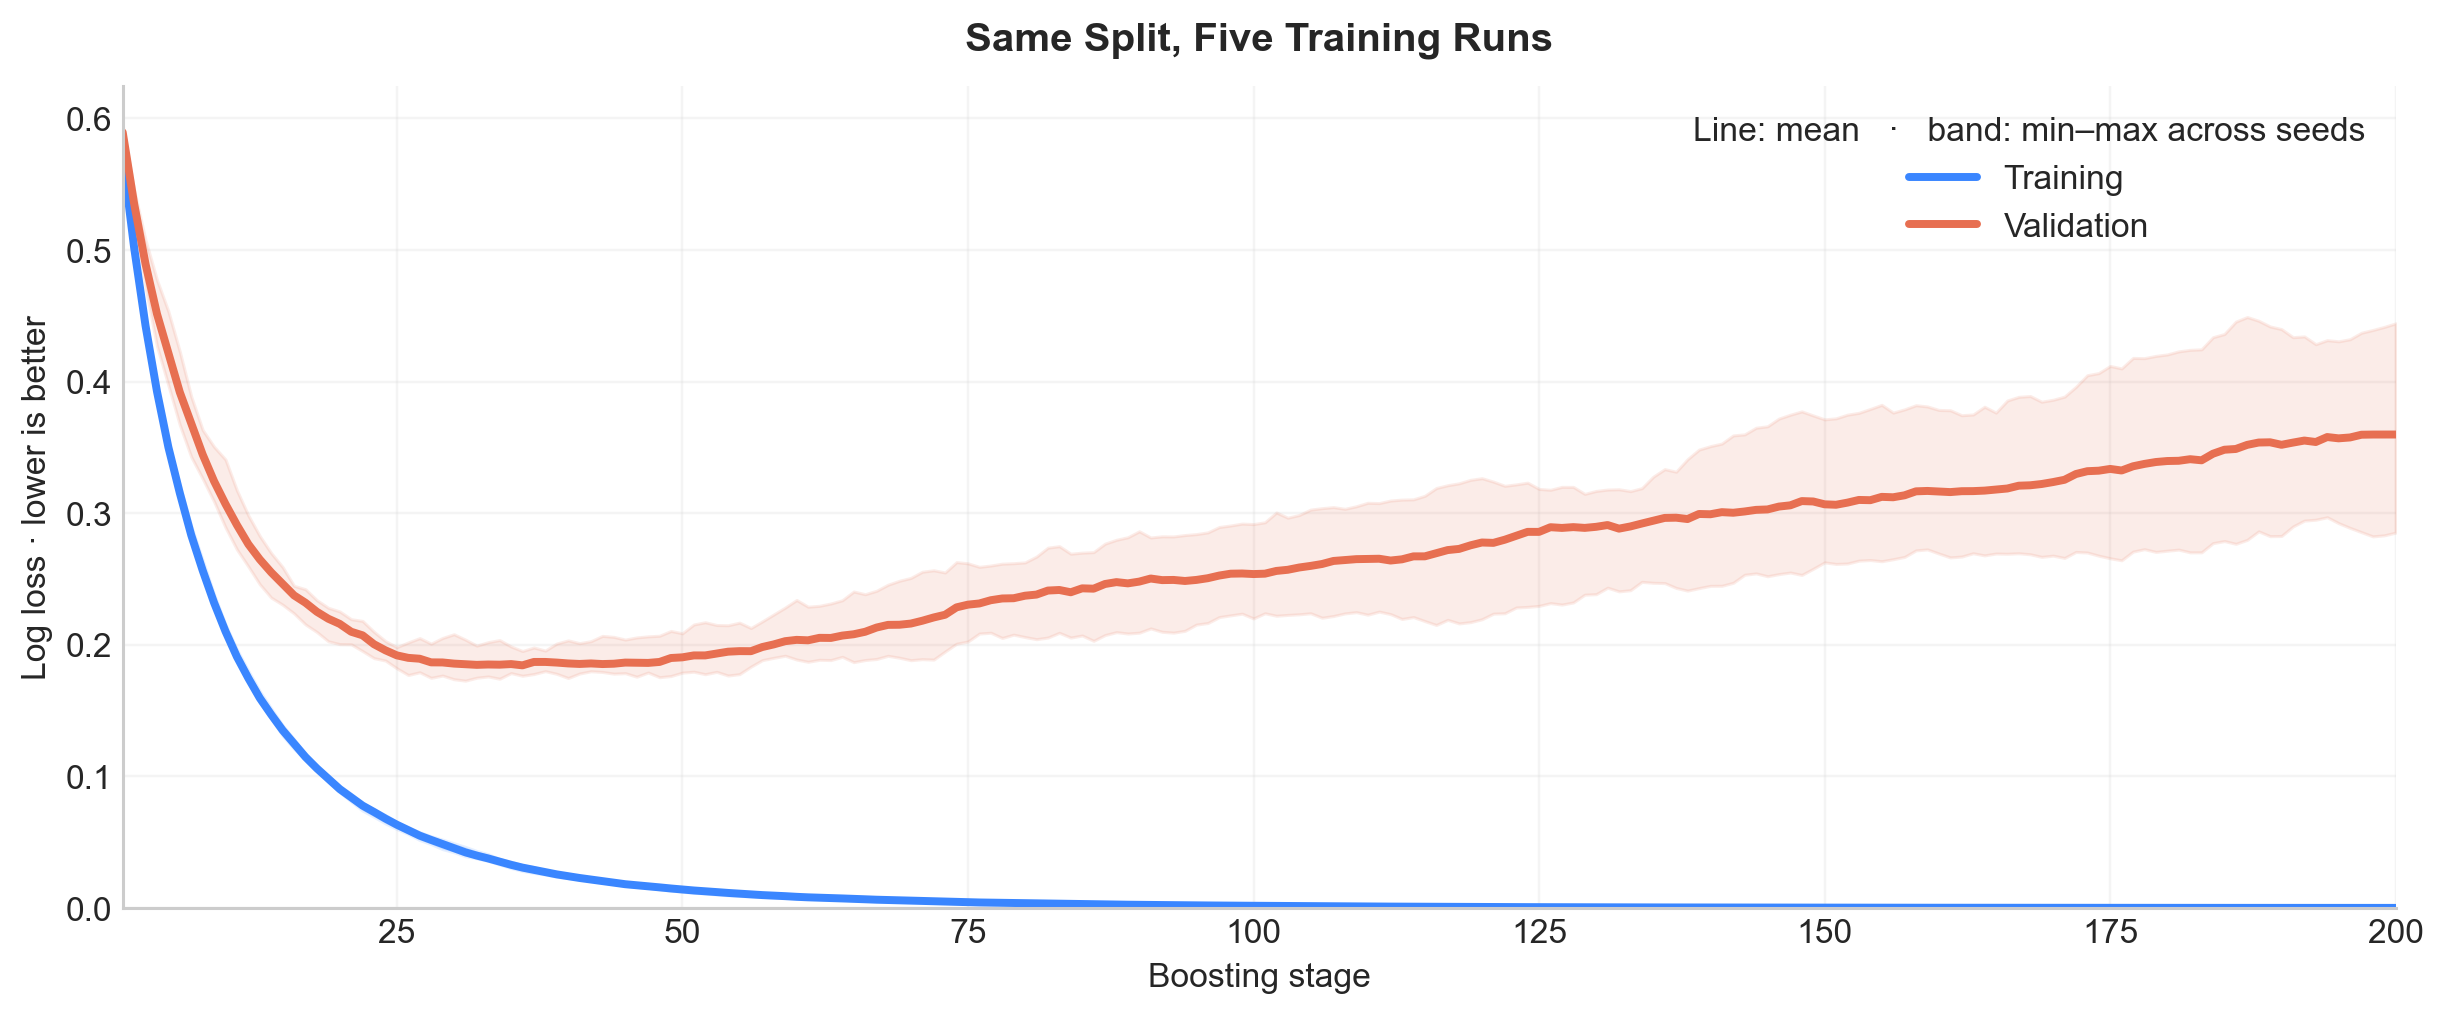

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss

curve_X, curve_y = load_breast_cancer(return_X_y=True)
curve_train_X, curve_val_X, curve_train_y, curve_val_y = train_test_split(
    curve_X, curve_y, train_size=100, stratify=curve_y, random_state=42)
learning_losses = {'Training': [], 'Validation': []}
for seed in range(5):
    curve_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                             max_depth=2, subsample=0.7, random_state=seed)
    curve_model.fit(curve_train_X, curve_train_y)
    for name, features, labels in [('Training', curve_train_X, curve_train_y),
                                    ('Validation', curve_val_X, curve_val_y)]:
        learning_losses[name].append([log_loss(labels, p) for p in curve_model.staged_predict_proba(features)])

fig, ax = plt.subplots(figsize=(11, 4.5), layout='constrained')
stages = np.arange(1, 201)
for name, color in [('Training', COLORS['blue']), ('Validation', COLORS['coral'])]:
    runs = np.array(learning_losses[name])
    ax.fill_between(stages, runs.min(axis=0), runs.max(axis=0), color=color, alpha=0.13)
    ax.plot(stages, runs.mean(axis=0), color=color, linewidth=2.6, label=name)
style_axes(ax, 'Same Split, Five Training Runs', 'Boosting stage', 'Log loss · lower is better')
ax.set(xlim=(1, 200), ylim=(0, None))
ax.legend(frameon=False, title='Line: mean   ·   band: min–max across seeds')
plt.show()

Training loss keeps improving, but validation loss eventually stops improving and rises. More fitting isn't always better generalization. We'd use validation to choose a stopping point, then evaluate the chosen procedure on an untouched test set; this demonstration hasn't reserved one. The band shows **variation across five seeds on one fixed split**, not a confidence interval or uncertainty across new datasets. Always say what an error band represents.

### 5 · A profile, or a precise comparison?

A community program is reviewing five areas. These **illustrative ratings** are invented for this chart comparison, all on the same 0–10 scale. Which area needs attention first? Which chart helps you explain why?

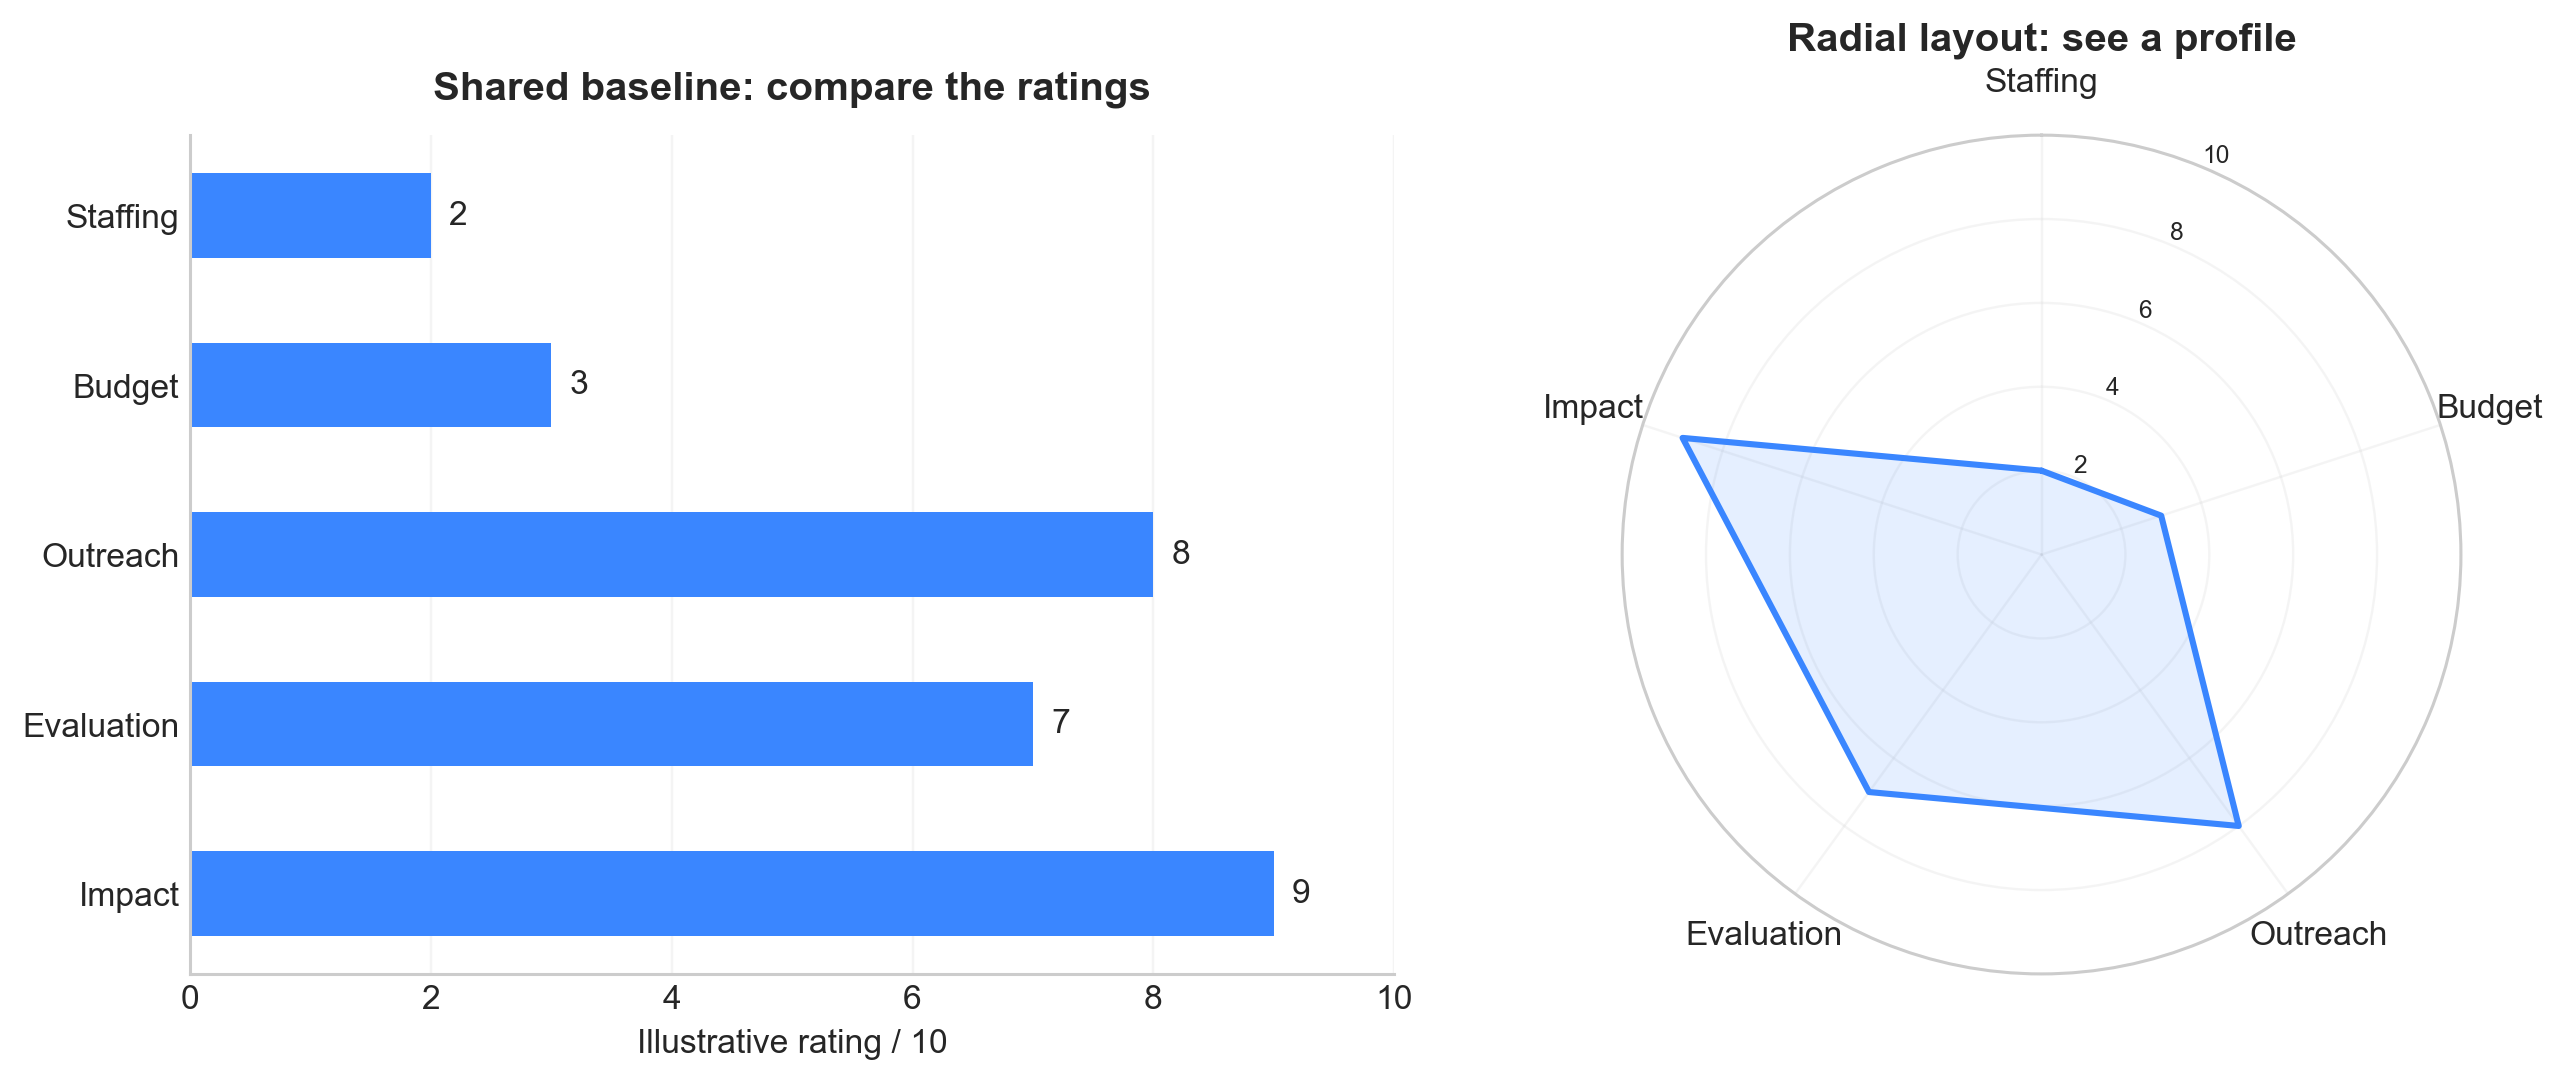

In [10]:
areas = ['Staffing', 'Budget', 'Outreach', 'Evaluation', 'Impact']
ratings = np.array([2, 3, 8, 7, 9])
fig = plt.figure(figsize=(12, 4.8), layout='constrained')
bar_ax = fig.add_subplot(1, 2, 1)
radar_ax = fig.add_subplot(1, 2, 2, projection='polar')
bar_ax.barh(areas, ratings, color=COLORS['blue'], height=0.5)
for i, rating in enumerate(ratings):
    bar_ax.text(rating + 0.15, i, str(rating), va='center')
bar_ax.invert_yaxis()
bar_ax.set_xlim(0, 10)
bar_ax.grid(axis='y', visible=False)
style_axes(bar_ax, 'Shared baseline: compare the ratings', 'Illustrative rating / 10')
angles = np.linspace(0, 2*np.pi, len(areas), endpoint=False)
radar_ax.set_theta_offset(np.pi / 2)
radar_ax.set_theta_direction(-1)
radar_ax.plot(np.r_[angles, angles[0]], np.r_[ratings, ratings[0]], color=COLORS['blue'], linewidth=2)
radar_ax.fill(np.r_[angles, angles[0]], np.r_[ratings, ratings[0]], color=COLORS['blue'], alpha=0.13)
radar_ax.set_xticks(angles, areas)
radar_ax.set_ylim(0, 10)
radar_ax.set_yticks([2, 4, 6, 8, 10])
radar_ax.tick_params(axis='y', labelsize=8)
radar_ax.tick_params(axis='x', pad=10)
radar_ax.set_title('Radial layout: see a profile', pad=28)
plt.show()

The bars make it easy to see that Staffing is one point below Budget. The radar chart creates a memorable profile, but its shape changes if we reorder the categories, even though the ratings haven't changed. Its area isn't an overall score. A radar chart can work when readers know the fixed axes; for comparing individual values, the common baseline is usually clearer. The question comes first, the chart comes second. Now let's apply that same habit to model evaluation.

## Part 3: Which Fraud Detector Would You Choose?

Let's evaluate two models on the same transactions. Start with accuracy alone. Is there enough information to choose?

In [11]:
fraud = pd.read_csv(data_path('creditcard.csv'))
if not fraud.Class.isin([0, 1]).all():
    raise ValueError('Class must contain only 0 (legitimate) and 1 (fraud).')
fraud = fraud.sample(n=min(50_000, len(fraud)), random_state=42)
fraud_X, fraud_y = fraud.drop(columns=['Time', 'Class']), fraud.Class
fraud_X_train, fraud_X_test, fraud_y_train, fraud_y_test = train_test_split(
    fraud_X, fraud_y, test_size=0.30, stratify=fraud_y, random_state=42)
# All fitted preprocessing stays inside the training pipeline.
# Scaling is not required for trees; it preserves the earlier lecture's setup.
fraud_model = make_pipeline(StandardScaler(), RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=2))
fraud_model.fit(fraud_X_train, fraud_y_train)
fraud_scores = fraud_model.predict_proba(fraud_X_test)[:, 1]
fraud_predictions = (fraud_scores >= 0.5).astype(int)
baseline_predictions = np.zeros(len(fraud_y_test), dtype=int)
compact_table(pd.DataFrame({
    'Model': ['A', 'B'],
    'Test accuracy': [accuracy_score(fraud_y_test, baseline_predictions),
                      accuracy_score(fraud_y_test, fraud_predictions)],
}), {'Test accuracy': '{:.3%}'})

Model,Test accuracy
A,99.833%
B,99.913%


### What did each model actually do?

Model A always predicts “legitimate.” Model B is a random forest. Read the bottom row of each matrix first: how many fraudulent transactions did each model catch? The percentages are calculated within each actual class; the counts tell us how much work those percentages represent.

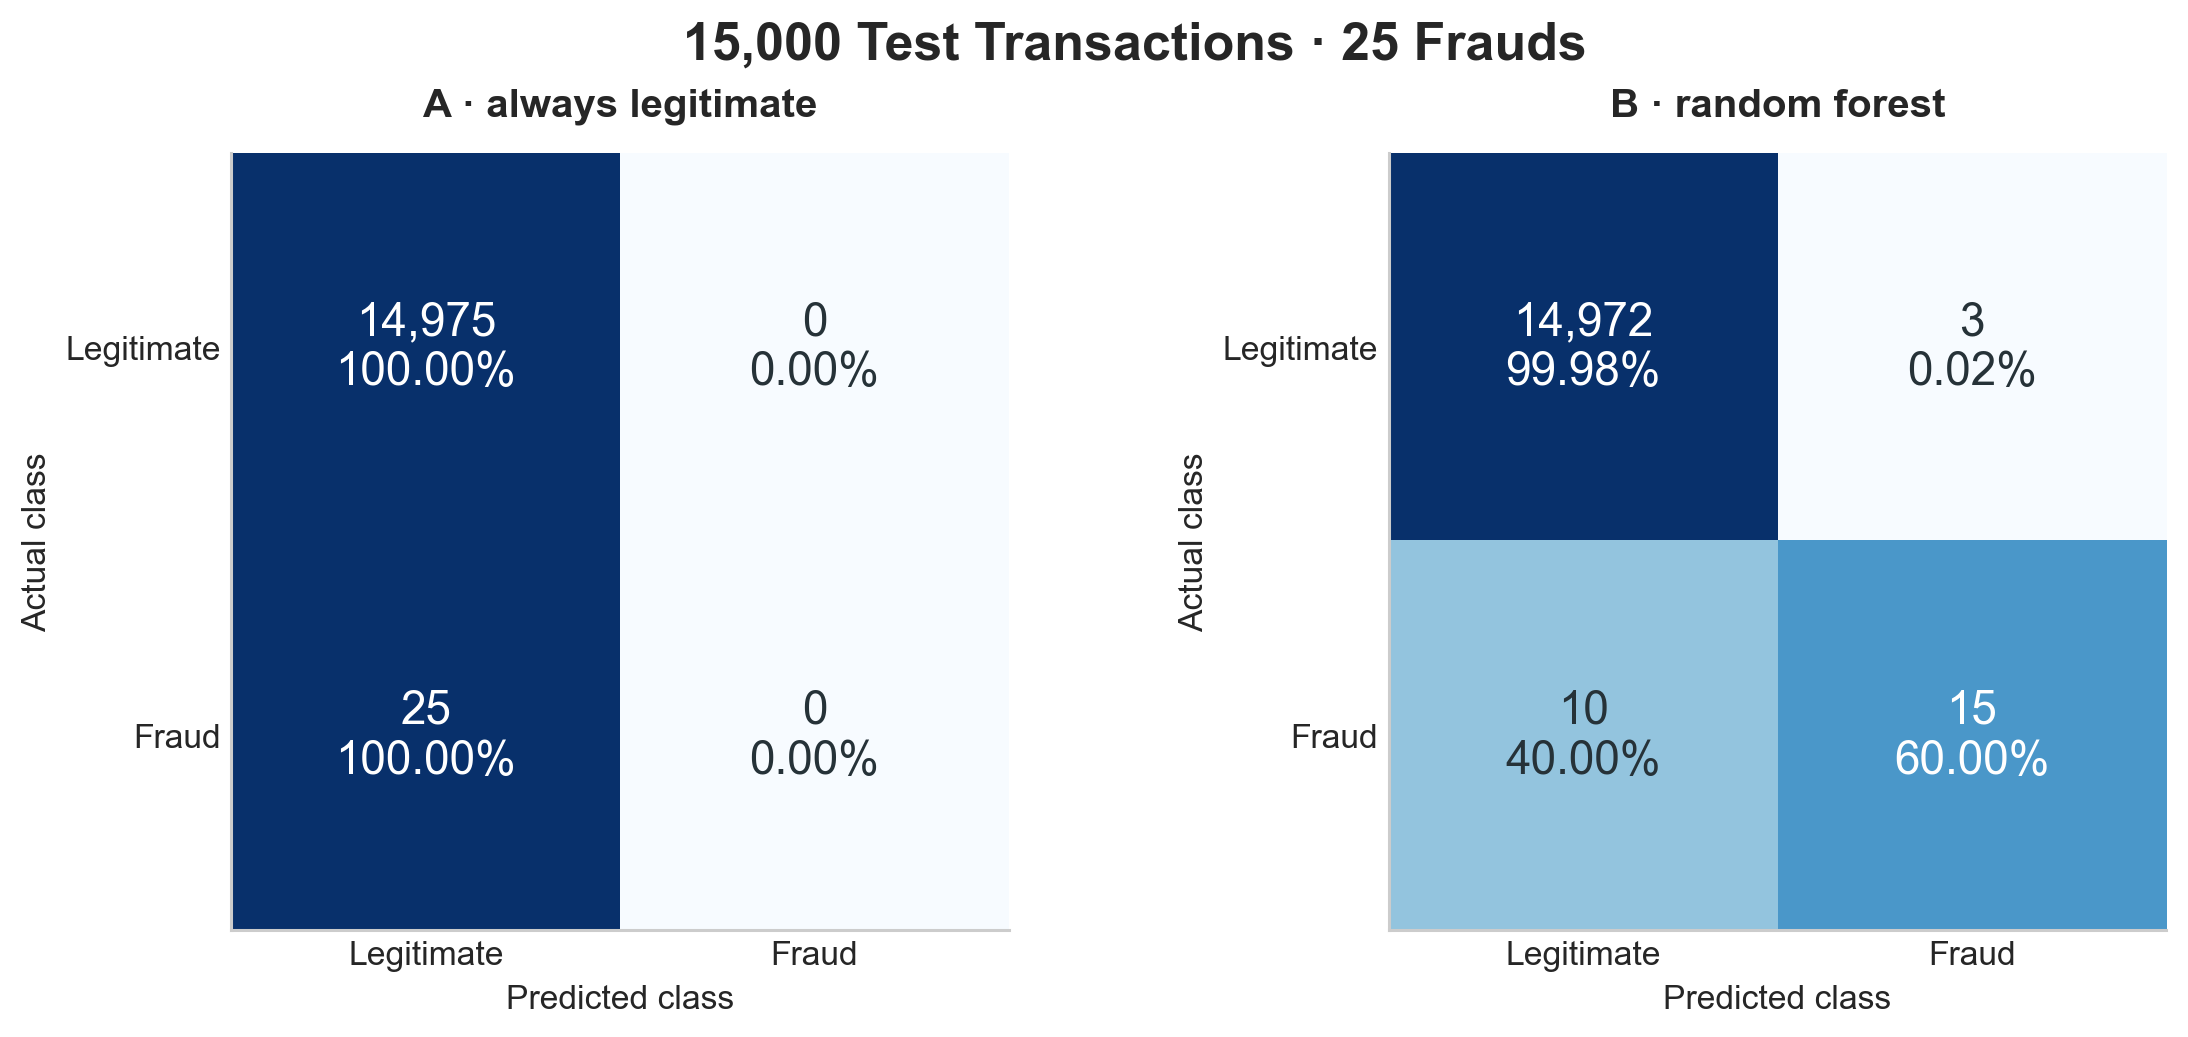

In [12]:
fraud_cm = confusion_matrix(fraud_y_test, fraud_predictions, labels=[0, 1])
tn, fp, fn, tp = fraud_cm.ravel()
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), layout='constrained')
for ax, name, prediction in zip(axes, ['A · always legitimate', 'B · random forest'],
                                [baseline_predictions, fraud_predictions]):
    cm = confusion_matrix(fraud_y_test, prediction, labels=[0, 1])
    row_rates = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(row_rates, cmap='Blues', vmin=0, vmax=1)
    for (r, c), count in np.ndenumerate(cm):
        ax.text(c, r, f'{count:,}\n{row_rates[r, c]:.2%}', ha='center', va='center',
                fontsize=15, color='white' if row_rates[r, c] > 0.55 else COLORS['ink'])
    ax.set_xticks([0, 1], ['Legitimate', 'Fraud'])
    ax.set_yticks([0, 1], ['Legitimate', 'Fraud'])
    ax.grid(False)
    style_axes(ax, name, 'Predicted class', 'Actual class')
fig.suptitle(f'{len(fraud_y_test):,} Test Transactions · {int(fraud_y_test.sum())} Frauds',
             fontsize=17, fontweight='bold')
plt.show()

The baseline earns its high accuracy by recognizing the majority class and missing every fraud. For the forest, **recall** asks how many frauds we caught; **precision** asks how many flagged transactions were actually fraud. F1 combines precision and recall, but still doesn't tell us the financial consequence of the errors.

In [13]:
compact_table(pd.DataFrame({
    'Frauds caught / all frauds': [f'{tp} / {tp + fn}'], 'Recall': [tp / (tp + fn)],
    'Actual frauds / all alerts': [f'{tp} / {tp + fp}'], 'Precision': [tp / (tp + fp)],
}), {'Recall': '{:.1%}', 'Precision': '{:.1%}'})

Frauds caught / all frauds,Recall,Actual frauds / all alerts,Precision
15 / 25,60.0%,15 / 18,83.3%


### Did we catch most of the money?

We already have each transaction's amount. Use those amounts directly: are the frauds we caught representative of the frauds we missed?

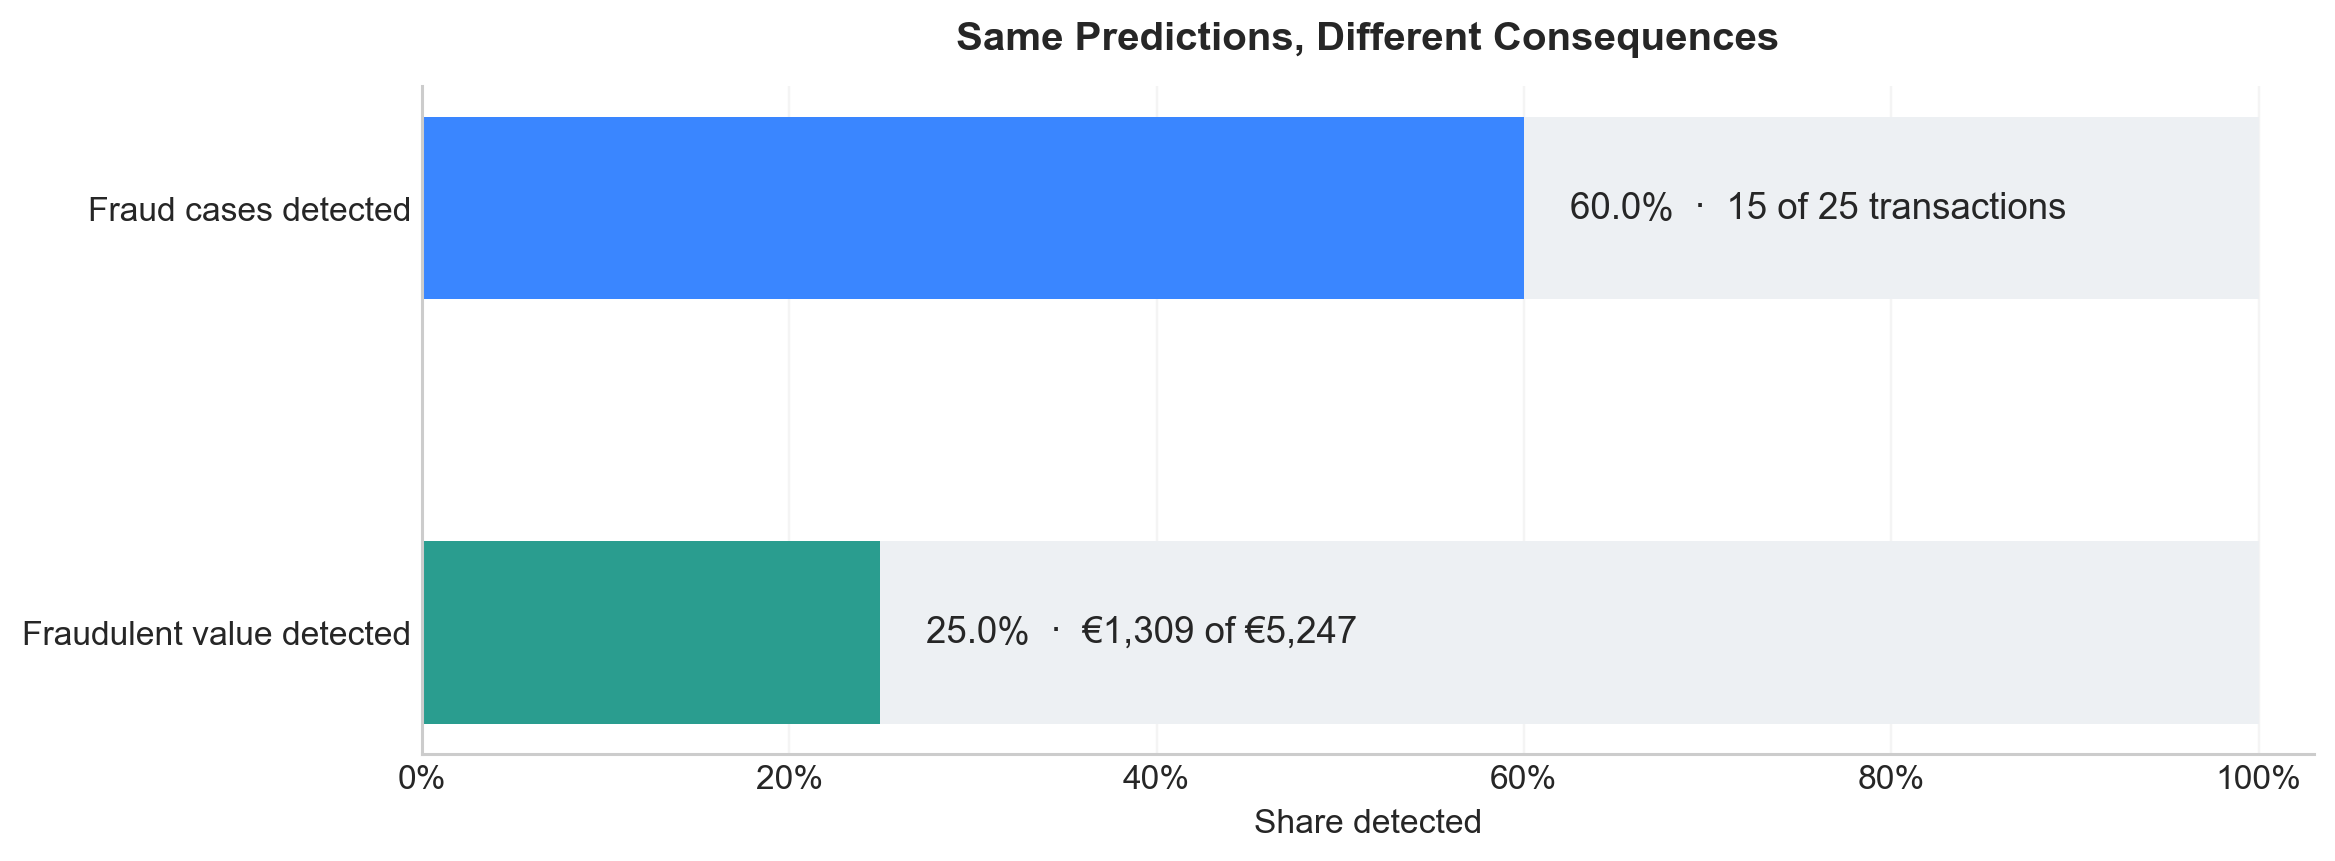

In [14]:
is_fraud = fraud_y_test.eq(1)
caught = is_fraud & (fraud_predictions == 1)
fraud_total_value = fraud_X_test.loc[is_fraud, 'Amount'].sum()
fraud_caught_value = fraud_X_test.loc[caught, 'Amount'].sum()
detected_shares = [tp / (tp + fn), fraud_caught_value / fraud_total_value]
fig, ax = plt.subplots(figsize=(10.5, 3.8), layout='constrained')
ax.barh([0, 1], [1, 1], color='#EDF0F3', height=0.43)
ax.barh([0, 1], detected_shares, color=[COLORS['blue'], COLORS['teal']], height=0.43)
details = [f'{tp} of {tp + fn} transactions', f'€{fraud_caught_value:,.0f} of €{fraud_total_value:,.0f}']
for i, (share, detail) in enumerate(zip(detected_shares, details)):
    ax.text(share + 0.025, i, f'{share:.1%}  ·  {detail}', va='center', fontsize=12)
ax.set_yticks([0, 1], ['Fraud cases detected', 'Fraudulent value detected'])
ax.set_xlim(0, 1.03)
ax.invert_yaxis()
ax.grid(axis='y', visible=False)
style_axes(ax, 'Same Predictions, Different Consequences', 'Share detected', percent_x=True)
plt.show()

Catching a large share of the cases doesn't guarantee catching a large share of their value. This measures fraudulent transaction value detected, not money saved: actual savings would depend on whether we could stop the transaction and on the cost of false alarms. Choosing the evaluation measure is part of defining the task.

## Part 4: What Changes When Fraud Becomes Rare?

ROC asks how often we catch fraud and how often we flag legitimate transactions. Precision asks a different question: among all our alerts, how many are fraud?

Here we keep the **same fitted model, scores, and labels** and change only the total weight of each class. This is a controlled prevalence experiment: it assumes the score distributions within each class stay fixed. It is not a claim about how the model will behave under every real distribution shift. The dots mark the same score cutoff, 0.5.

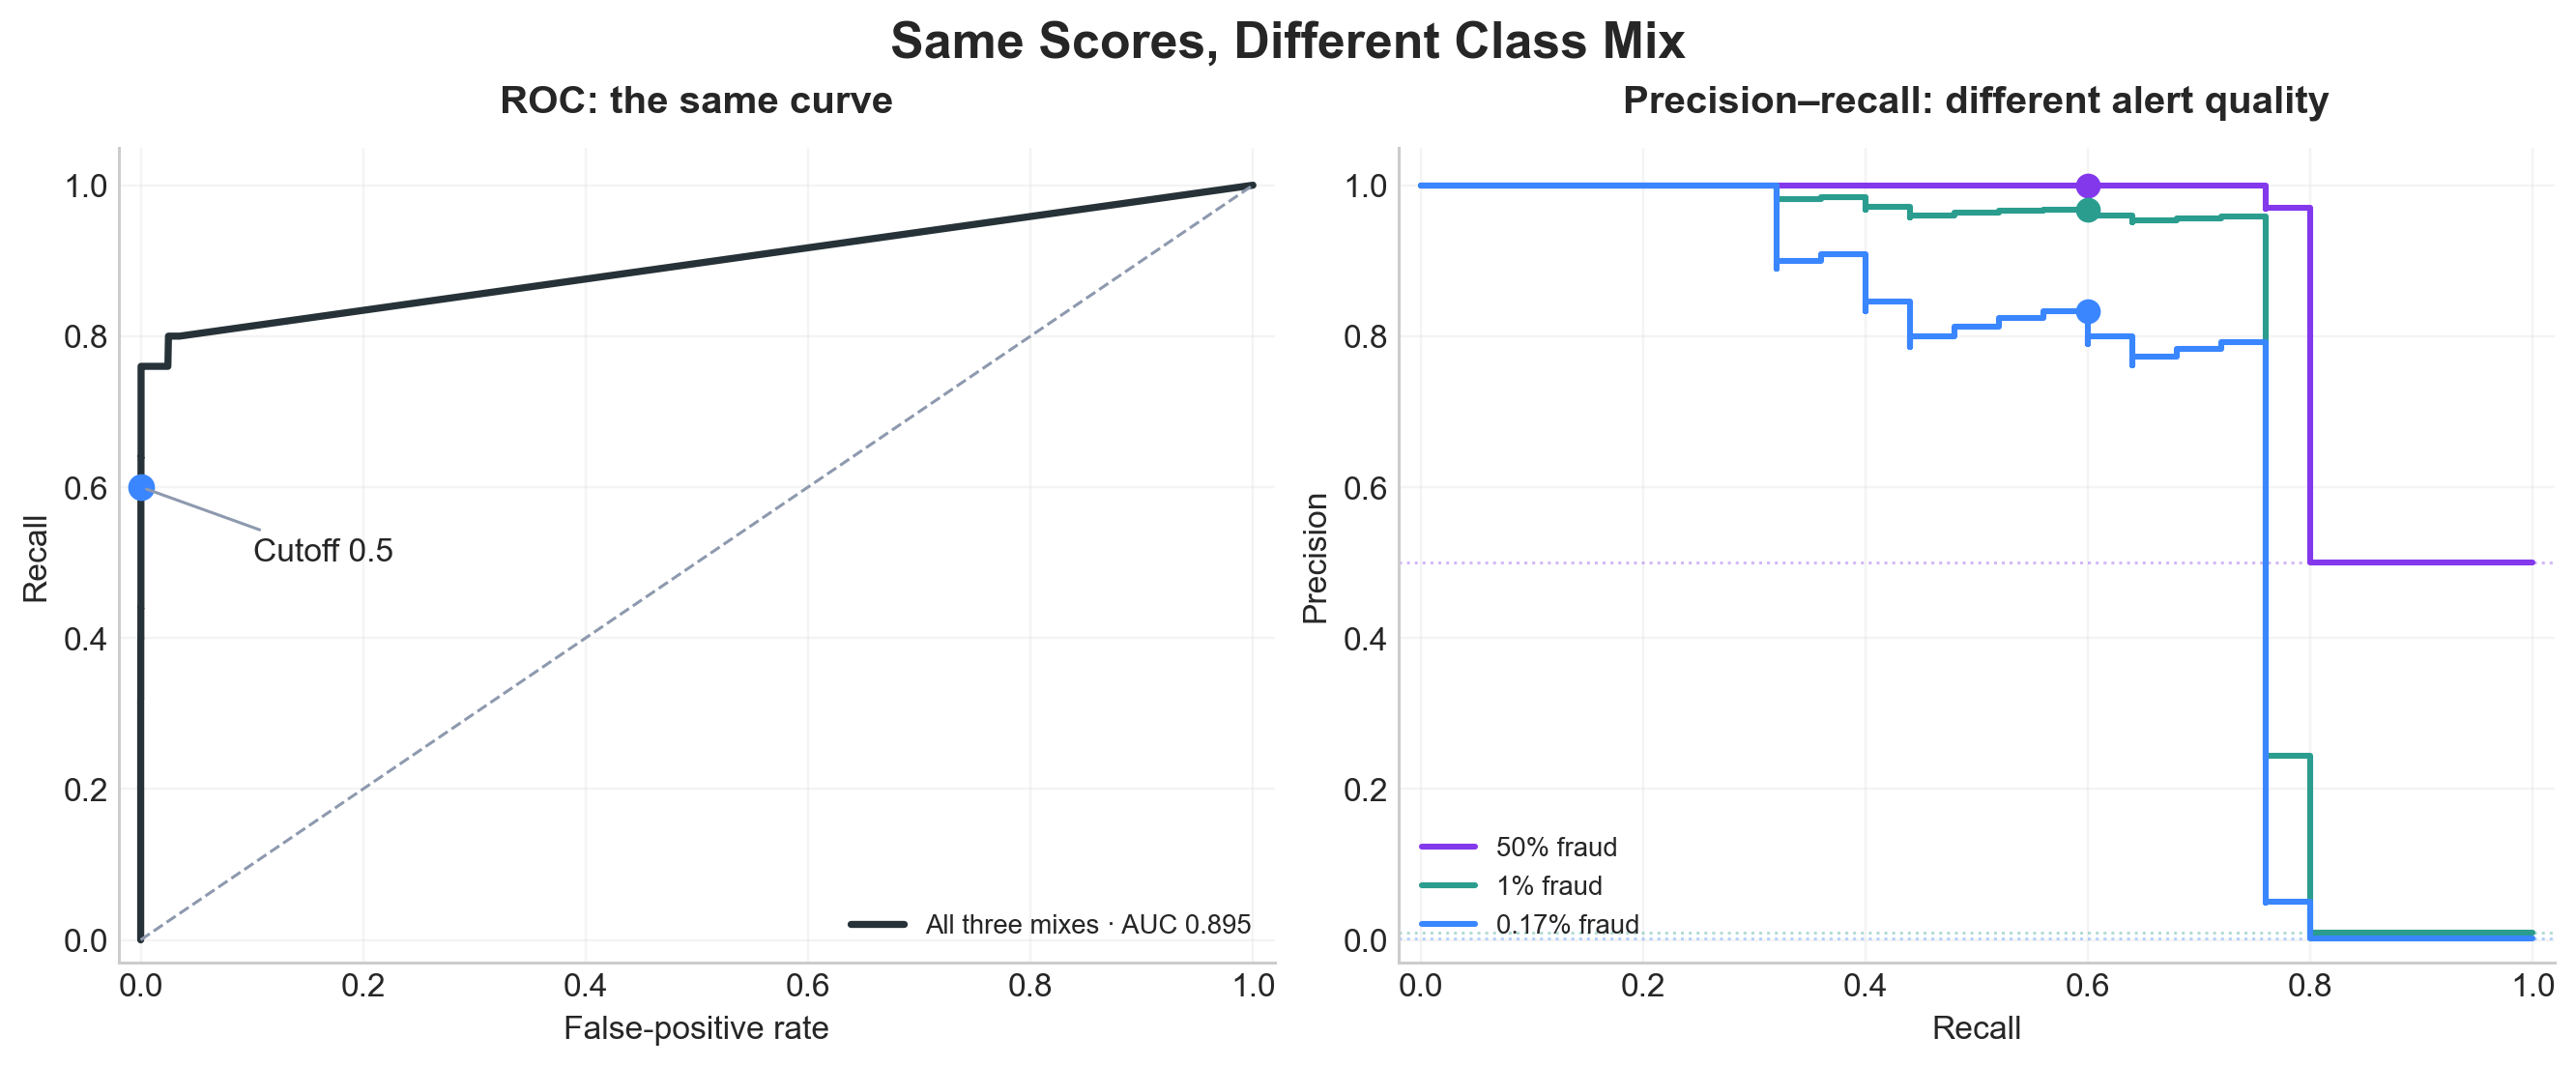

In [15]:
observed_prevalence = fraud_y_test.mean()
fpr, tpr, _ = roc_curve(fraud_y_test, fraud_scores)
operating_fpr, operating_tpr = fp / (fp + tn), tp / (tp + fn)
prevalences = [0.50, 0.01, observed_prevalence]
prevalence_colors = [COLORS['purple'], COLORS['teal'], COLORS['blue']]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.9), layout='constrained')
axes[0].plot(fpr, tpr, color=COLORS['ink'], linewidth=2.4,
             label=f'All three mixes · AUC {roc_auc_score(fraud_y_test, fraud_scores):.3f}')
axes[0].plot([0, 1], [0, 1], '--', color=COLORS['muted'], linewidth=1)
axes[0].scatter(operating_fpr, operating_tpr, color=COLORS['blue'], s=65, zorder=3)
axes[0].annotate('Cutoff 0.5', (operating_fpr, operating_tpr), xytext=(38, -25),
                 textcoords='offset points', arrowprops={'arrowstyle': '-', 'color': COLORS['muted']})
for prevalence, color in zip(prevalences, prevalence_colors):
    weights = np.where(fraud_y_test.eq(1), prevalence / observed_prevalence,
                       (1 - prevalence) / (1 - observed_prevalence))
    precision, recall, _ = precision_recall_curve(fraud_y_test, fraud_scores, sample_weight=weights)
    label = f'{prevalence:.2%} fraud' if prevalence == observed_prevalence else f'{prevalence:.0%} fraud'
    axes[1].step(recall, precision, where='post', color=color, linewidth=2, label=label)
    operating_precision = (prevalence * operating_tpr /
                           (prevalence * operating_tpr + (1 - prevalence) * operating_fpr))
    axes[1].scatter(operating_tpr, operating_precision, color=color, s=55, zorder=3)
    axes[1].axhline(prevalence, color=color, linestyle=':', alpha=0.35, linewidth=1)
for ax in axes:
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.03, 1.05)
    ax.legend(frameon=False, fontsize=9, loc='lower left' if ax is axes[1] else 'lower right')
style_axes(axes[0], 'ROC: the same curve', 'False-positive rate', 'Recall')
style_axes(axes[1], 'Precision–recall: different alert quality', 'Recall', 'Precision')
fig.suptitle('Same Scores, Different Class Mix', fontsize=17, fontweight='bold')
plt.show()

The ROC curve stays fixed because each rate is calculated within one class. Precision changes because the alert pool combines both classes. The dotted PR baselines show the fraud prevalence in each scenario. Neither curve is lying; they answer different questions.

For a quick whiteboard example, imagine 100 frauds and 99,900 legitimate transactions. At 80% recall and a 1% false-positive rate, we get 80 genuine alerts and 999 false alarms. Only about 7% of the alerts are fraud.

## Part 5: How Much Should We Trust This Test?

Our test set contains only 25 frauds, so finding one more changes recall by four percentage points. That's a useful reminder of how much can hide behind a precise-looking percentage.

**Training data → fit the model. Validation data → choose settings and thresholds. Test data → report the final result.** We fixed the settings and 0.5 cutoff for this demonstration; we haven't searched for the best threshold on the test set. If we wanted to tune it, we'd reserve validation data from the training portion first.

On the whiteboard, compare repeated or cross-validated estimates with a single split, then ask what “new data” means. For new patients, keep each patient's records together. For future transactions, train on earlier data and evaluate later data. A random split, like the one above, answers a narrower question. Any fitted preprocessing must stay inside the training portion of each split.

## Part 6: Could We Have Known This in Time?

Imagine we want to contact customers **before they leave**. IBM's Telco sample describes a fictional company. Take a look at a few records, then ask which fields we could have known at the moment we wanted to act.

For this classroom comparison, we treat tenure, charges, and contract as baseline inputs. The file is a snapshot, not a history of customer states, so even the baseline would need a proper timestamp audit before use in a real forecasting task.

In [16]:
telco = pd.read_excel(data_path('Telco_customer_churn.xlsx'), engine='openpyxl')
assert {'Churn Reason', 'Churn Label', 'Tenure Months'}.issubset(telco.columns), 'Use the 33-column IBM workbook.'
numeric_features = ['Tenure Months', 'Monthly Charges', 'Total Charges']
categorical_features = ['Contract']
for feature in numeric_features:
    telco[feature] = pd.to_numeric(telco[feature], errors='coerce')
telco = telco.dropna(subset=numeric_features).reset_index(drop=True)
examples = telco.groupby('Churn Label', group_keys=False).head(2)
compact_table(examples[['Contract', 'Tenure Months', 'Churn Reason', 'Churn Label']]
              .fillna('—').rename(columns={'Churn Label': 'Left?'}))

Contract,Tenure Months,Churn Reason,Left?
Month-to-month,2,Competitor made better offer,Yes
Month-to-month,2,Moved,Yes
Month-to-month,1,—,No
One year,34,—,No


### One extra field

Compare the same random forest and split with and without a flag indicating whether `Churn Reason` was recorded. Then keep that second model fixed and set the flag to zero for every test record. This removes the future information; it does not simulate every aspect of deployment.

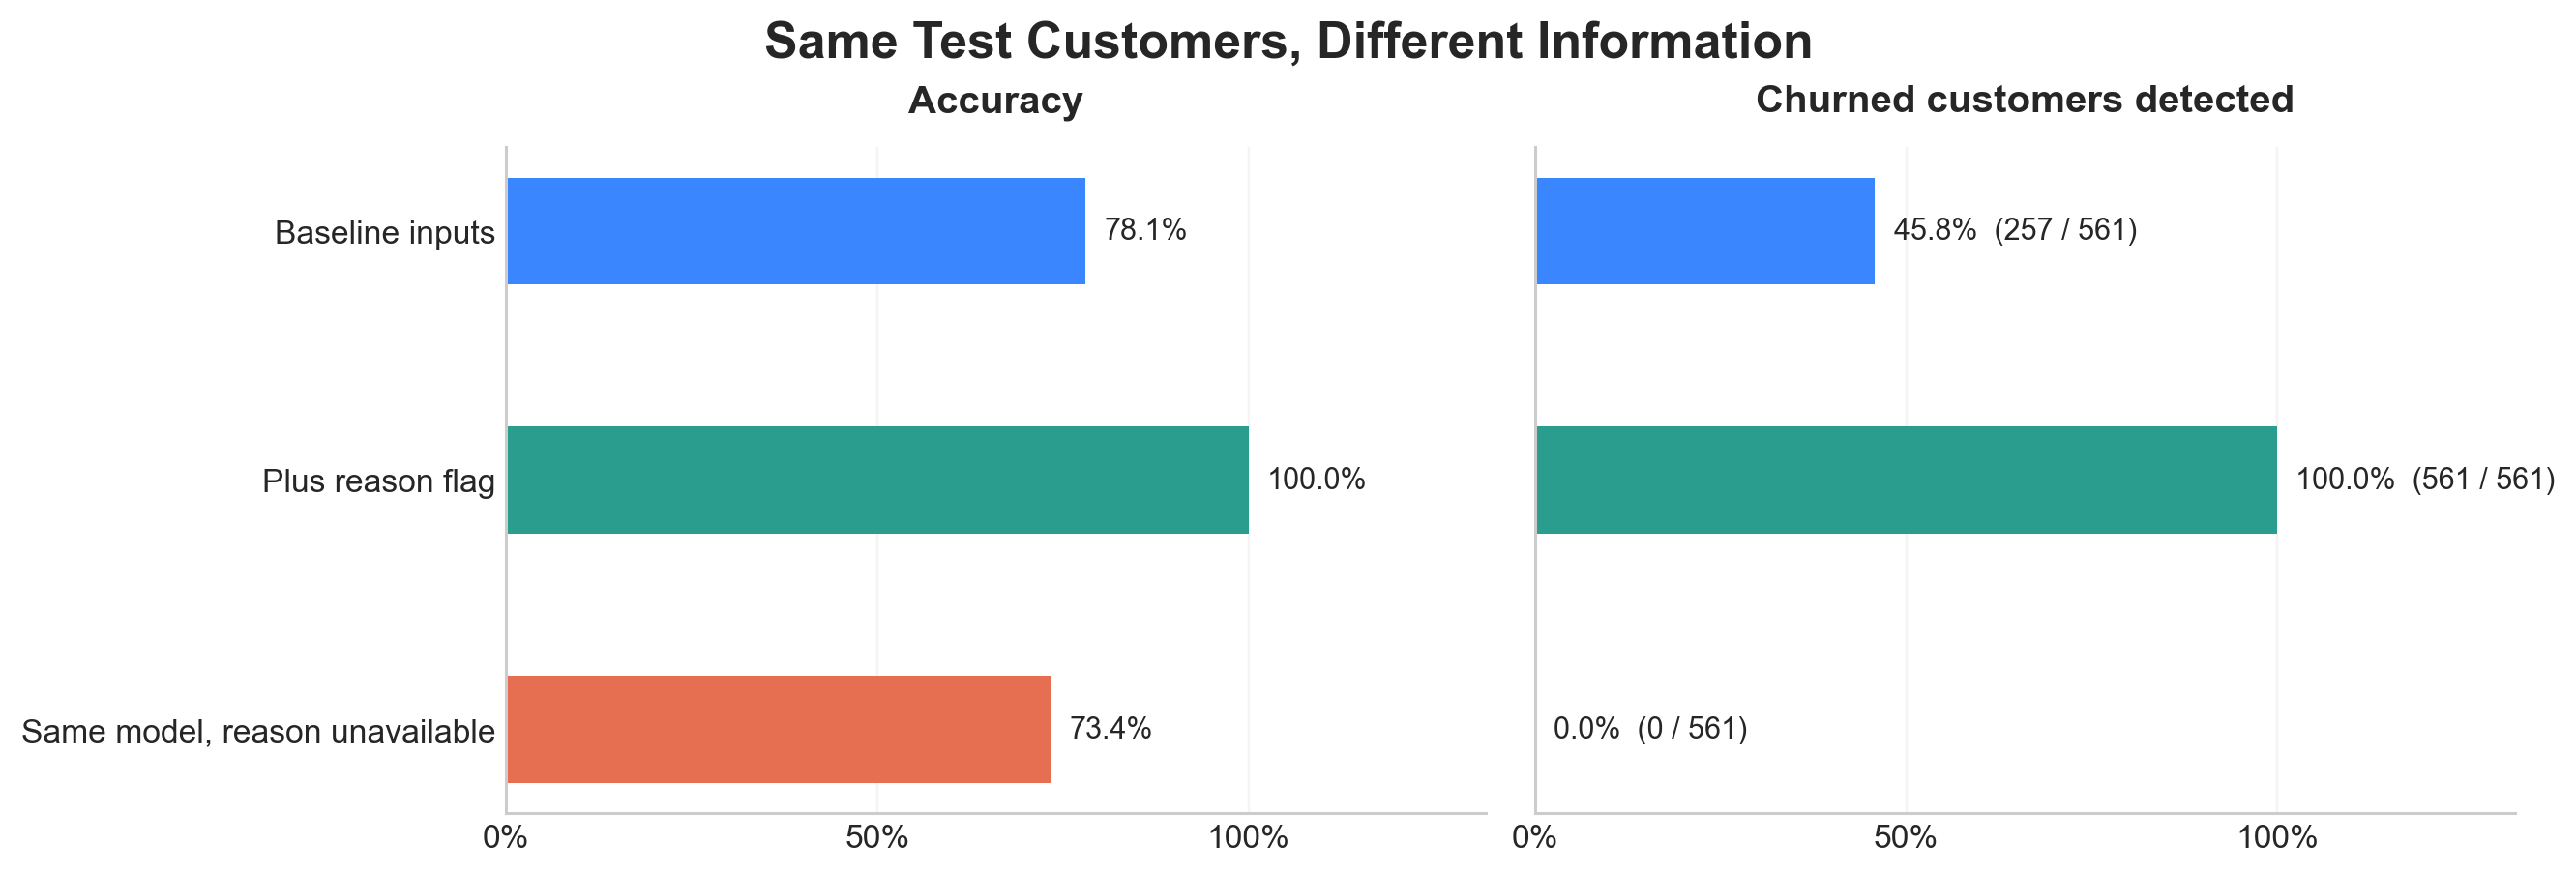

In [17]:
telco_y = telco['Churn Label'].eq('Yes').astype(int)
telco_X = telco[numeric_features + categorical_features].copy()
telco_X['Reason recorded'] = telco['Churn Reason'].fillna('').str.strip().ne('').astype(int)
telco_train, telco_test = train_test_split(np.arange(len(telco)), test_size=0.30,
                                         stratify=telco_y, random_state=42)
telco_models = {}
for name, extra in [('Baseline inputs', []), ('Plus reason flag', ['Reason recorded'])]:
    preprocessing = ColumnTransformer([
        ('numeric', 'passthrough', numeric_features + extra),
        ('category', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ])
    model = make_pipeline(preprocessing, RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=2))
    model.fit(telco_X.iloc[telco_train], telco_y.iloc[telco_train])
    telco_models[name] = model

without_future = telco_X.iloc[telco_test].assign(**{'Reason recorded': 0})
scenarios = [
    ('Baseline inputs', telco_models['Baseline inputs'], telco_X.iloc[telco_test]),
    ('Plus reason flag', telco_models['Plus reason flag'], telco_X.iloc[telco_test]),
    ('Same model, reason unavailable', telco_models['Plus reason flag'], without_future),
]
leakage_rows = []
for label, model, frame in scenarios:
    prediction = model.predict(frame)
    n_tn, n_fp, n_fn, n_tp = confusion_matrix(telco_y.iloc[telco_test], prediction).ravel()
    leakage_rows.append({'Scenario': label, 'Accuracy': (n_tp + n_tn) / len(frame),
                         'Recall': n_tp / (n_tp + n_fn), 'Caught': n_tp, 'Missed': n_fn})
leakage_results = pd.DataFrame(leakage_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, layout='constrained')
scenario_colors = [COLORS['blue'], COLORS['teal'], COLORS['coral']]
for ax, metric, title in zip(axes, ['Accuracy', 'Recall'], ['Accuracy', 'Churned customers detected']):
    ax.barh(np.arange(3), leakage_results[metric], color=scenario_colors, height=0.43)
    for i, row in leakage_results.iterrows():
        label = f'{row[metric]:.1%}'
        if metric == 'Recall':
            label += f'  ({row.Caught} / {row.Caught + row.Missed})'
        ax.text(row[metric] + 0.025, i, label, va='center', fontsize=10)
    ax.set_xlim(0, 1.32)
    ax.set_xticks([0, 0.5, 1])
    ax.grid(axis='y', visible=False)
    style_axes(ax, title, percent_x=True)
axes[0].set_yticks(np.arange(3), leakage_results.Scenario)
axes[0].invert_yaxis()
fig.suptitle('Same Test Customers, Different Information', fontsize=17, fontweight='bold')
plt.show()

**Predict while the customer is active → observe whether they leave → record why they left.** In this file, the presence of a churn reason gives away the answer. A random split can't protect us when that field is supplied for the test customers too. Removing it exposes what the model was relying on, but neither this intervention nor the baseline score is a measured production result.

**Discussion:** what if the answer key is in an AI agent's conversation history or accessible files instead of a spreadsheet column? A held-out list of questions is only useful if the evaluation also controls what the system can access.

## Wrap-Up

A useful evaluation starts by asking what a number leaves out. Plotting reveals structure that summary statistics miss; looking within groups explains why an overall average can change; and counting errors tells us what a high accuracy score actually accomplished. The consequences may still look different when we count money instead of cases. Finally, the test must match the question we care about: what data is new, what decisions were already fixed, and what information was available when the prediction had to be made? A strong score becomes useful evidence only when we can answer those questions.

**Sources:** [Datasaurus Dozen](https://www.openintro.org/data/index.php?data=datasaurus), [Berkeley admissions documentation](https://www.stat.ethz.ch/R-manual/R-devel/library/datasets/html/UCBAdmissions.html), [European credit card transactions](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud), and [IBM Telco sample and field descriptions](https://community.ibm.com/community/user/blogs/steven-macko/2019/07/11/telco-customer-churn-1113). Datasaurus is deliberately constructed; Telco describes a fictional company. The prevalence comparison is an explicitly weighted experiment.